# Statistical Process Control
### ECE 8803-AI4 — course notebooks

Three problem sets on statistical process control, worked end to end. Run the notebook from
top to bottom: each problem states what is being asked, computes it from the data in `data/`,
plots the result, and then discusses what the result means.

**The running process.** Tool ETCH-03, poly gate layer, gate critical dimension (CD).
Target **45.0 nm**, specification **43.0 – 47.0 nm**, so the tolerance is 4.0 nm. Every
dataset comes from this process or from the metrology that measures it.

**Constants used throughout:** d₂(2) = 1.128, d₂(5) = 2.326, A₂(5) = 0.577, D₃(5) = 0,
D₄(5) = 2.114, D₄(2) = 3.267.

**How to read it.** Nothing is hard-coded — every number comes from the CSVs, so you can
change a dataset, a window or a rule set and watch the conclusions move. The two simulated
problems (HW1 P3 and P4) use fixed seeds, so your run reproduces exactly what you see here.

Each problem set opens with a look at its raw data. Run those cells first and form an
expectation before reading the analysis. The last part of every problem is the part that
matters: what the number means, and what you would do about it.

In [1]:
# ---------------------------------------------------------------- setup
# Fetches the datasets if they are not already beside the notebook. Running the notebook
# from a clone does nothing here; opening it straight in Colab downloads the nine CSVs.
from pathlib import Path
import urllib.request
from urllib.parse import quote

REPO = "aikhan123/ece8803-ai4-notebooks"
MODULE = "Module 6 SPC"     # the module folder inside the repo
BRANCH = "main"

FILES = ["hw1_cd_individuals.csv", "hw2_cd_subgroups.csv", "hw2_etch_ar1.csv",
         "hw2_probe_yield.csv", "hw3_gauge_study_A.csv", "hw3_gauge_study_B.csv",
         "hw3_etch_seasoning.csv", "hw3_fdc.csv", "hw3_r2r_loop.csv"]

if not any((p / "hw1_cd_individuals.csv").exists()
           for p in (Path("data"), Path("../data"))):
    base = f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{quote(MODULE)}/data/"
    Path("data").mkdir(exist_ok=True)
    for f in FILES:
        urllib.request.urlretrieve(base + f, Path("data") / f)
    print(f"downloaded {len(FILES)} datasets from {REPO}")
else:
    print("datasets already present — nothing to download")

datasets already present — nothing to download


In [2]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---- locate the data directory whether the notebook is run from its own folder or above
DATA = next(p for p in (Path("data"), Path("../data"), Path("notebook/data"), Path("."))
            if (p / "hw1_cd_individuals.csv").exists())
print("data directory:", DATA)

# ---- SPC constants
D2 = {2: 1.128, 3: 1.693, 4: 2.059, 5: 2.326}
A2 = {5: 0.577}
D3 = {5: 0.0}
D4 = {2: 3.267, 5: 2.114}

LSL, USL, TGT = 43.0, 47.0, 45.0
TOL = USL - LSL

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.figsize": (10, 3.4), "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})

BLUE, RED, GREY = "#31708e", "#c1392b", "#7f7f7f"
RESULTS = {}          # headline numbers, checked at the end

data directory: data


In [3]:
def sigma_from_mr(x):
    "Short-term sigma from the average moving range of individuals."
    return np.abs(np.diff(np.asarray(x))).mean() / D2[2]


def run_rules(y, cl, s):
    '''Western-Electric rules 1-5. Returns {rule: [1-based end index of each violation]}.

    1: one point beyond 3 sigma          2: two of three beyond 2 sigma, same side
    3: four of five beyond 1 sigma       4: nine in a row on one side
    5: six in a row steadily increasing or decreasing
    '''
    y = np.asarray(y, float)
    z = (y - cl) / s
    r1 = [i + 1 for i in range(len(y)) if abs(z[i]) > 3]

    side, c, r4 = np.sign(z), 1, []
    for i in range(1, len(y)):
        c = c + 1 if side[i] == side[i - 1] and side[i] != 0 else 1
        if c >= 9:
            r4.append(i + 1)

    r5 = [i + 1 for i in range(5, len(y))
          if np.all(np.diff(y[i - 5:i + 1]) > 0) or np.all(np.diff(y[i - 5:i + 1]) < 0)]

    r2 = [i + 1 for i in range(2, len(y)) for sgn in (1, -1)
          if (sgn * z[i - 2:i + 1] > 2).sum() >= 2 and sgn * z[i] > 2]
    r3 = [i + 1 for i in range(4, len(y)) for sgn in (1, -1)
          if (sgn * z[i - 4:i + 1] > 1).sum() >= 4 and sgn * z[i] > 1]

    return {"1": r1, "2": sorted(set(r2)), "3": sorted(set(r3)), "4": r4, "5": r5}


def chart(y, cl, lcl, ucl, title, ylabel="", xlabel="lot", x=None,
          viol=(), spec=(), ax=None, marks=()):
    "Draw one control chart. `viol` and `marks` are 1-based indices."
    y = np.asarray(y, float)
    x = np.arange(1, len(y) + 1) if x is None else np.asarray(x)
    if ax is None:
        _, ax = plt.subplots()
    ax.plot(x, y, "o-", ms=3.4, lw=1.0, color=BLUE, zorder=2)
    ax.axhline(cl, color="k", lw=1.1)
    for lim, lab in ((ucl, "UCL"), (lcl, "LCL")):
        if lim is not None:
            ax.axhline(lim, color=RED, lw=1.1, ls="--")
            ax.annotate(f"{lab} {lim:.3g}", (x[-1], lim), xytext=(4, 0),
                        textcoords="offset points", color=RED, va="center", fontsize=8)
    for lim in spec:
        ax.axhline(lim, color=GREY, lw=1.0, ls=":")
    if len(viol):
        idx = np.asarray(viol, int) - 1
        ax.plot(x[idx], y[idx], "o", ms=9, mfc="none", mec=RED, mew=1.6, zorder=3)
    for m in marks:
        ax.axvline(m, color="#d08c00", lw=1.0, ls="-.", alpha=0.8)
    ax.set_title(title, loc="left", fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    return ax

---
# HW1 — Foundations

**What this set covers.** How a process is described statistically, where its variation
actually lives, what averaging buys you, and what happens when a well-intentioned operator
acts on every measurement. Four problems; only P1 has a dataset.

**The setting.** Tool ETCH-03, poly gate layer, gate critical dimension. Target 45.0 nm,
specification 43.0 – 47.0 nm.

### P1 — Characterise the process
*Data: `hw1_cd_individuals.csv`*

Compute the sample mean and standard deviation (n − 1). Compute the distance from the mean to
each specification limit in units of σ, and from those the ppm expected to fall above USL and
below LSL **separately**, then the total ppm and the parametric yield. Report how far the
process sits from target and which side of the specification carries most of the loss.

Then: this yield figure is one number about one parameter at one process step. What does it
tell you about the yield of a finished die, and what does it not? How much confidence do you
place in the ppm estimate, and what assumption does it rest on?

### P2 — The variance budget, and the inversion

An engineering study decomposes the CD variation on this layer into three independent
sources: within-wafer σ = 2.4 nm, wafer-to-wafer σ = 1.8 nm, lot-to-lot σ = 1.1 nm.

Compute σ_total, and show what simply adding the three σ values would have given. Tabulate
each source's variance and its share of the total. Then invert the question: you are asked to
reach σ_total = 2.5 nm by attacking **one** component. For each of the three, work out what
that component would have to fall to, and flag any that cannot reach the target *even if
driven to exactly zero* — reporting the floor it would leave you at.

Then: reducing within-wafer variation requires a new chamber kit and a six-month
qualification; reducing lot-to-lot variation is a cheap incoming-material change. Which do you
recommend, and why?

### P3 — Sampling distribution

Using the mean and σ measured in P1, simulate 5,000 individual measurements and 1,000
subgroups of n = 5. Report the standard deviation of the individuals, the standard deviation
of the 1,000 subgroup **means**, and the ratio of the two against √5. Account for any gap
between the simulated ratio and the theoretical one. Plot both distributions together.

Then: why does averaging shrink the spread while a genuine shift in the process mean is
unaffected by it? What does that imply for the sensitivity of an X̄ chart against a chart of
individuals? Is the gain proportional to n or to √n, and what does that say about the value of
a sixth wafer?

### P4 — The tampering simulation

A stable process, on target, σ = 1, 300 lots. Simulate two operating policies driven by the
**same** noise sequence: leave it alone, or adjust after every lot by the full observed
deviation. Report the standard deviation of the output under each policy and the ratio between
them, and compare that ratio with the theoretical value for full correction.

The correction must be **carried forward** — the adjustment made after lot *i* is still in
effect when lot *i + 1* is produced. A simulation that omits this finds no difference between
the policies.

Then: explain the mechanism. Why does correcting after every lot make things worse, when every
individual correction looked justified at the time? Name one place this happens in a real fab.

### The data for HW1

**`hw1_cd_individuals.csv` — 100 rows, 2 columns**

| column | meaning |
|---|---|
| `lot` | production lot number, 1–100, in time order |
| `cd_nm` | gate CD in nanometres — one measurement per lot |

One wafer was measured per lot, at one site, on one metrology tool, over roughly four weeks of
production. There is no subgrouping: each lot contributes a single number, which is the
simplest and most common form in which process data arrives.

P2, P3 and P4 need no file — P2 is given three variance components, and P3 and P4 are
simulations run below with fixed seeds.

hw1_cd_individuals.csv — 100 rows x 2 cols: one CD measurement per lot


,lot,cd_nm
0,1,45.4930
1,2,44.8120
2,3,47.0100
3,4,44.1050
4,5,45.6520


,count,mean,std,min,25%,50%,75%,max
cd_nm,100.0000,45.2000,0.6800,43.6990,44.8023,45.1590,45.6587,47.6980


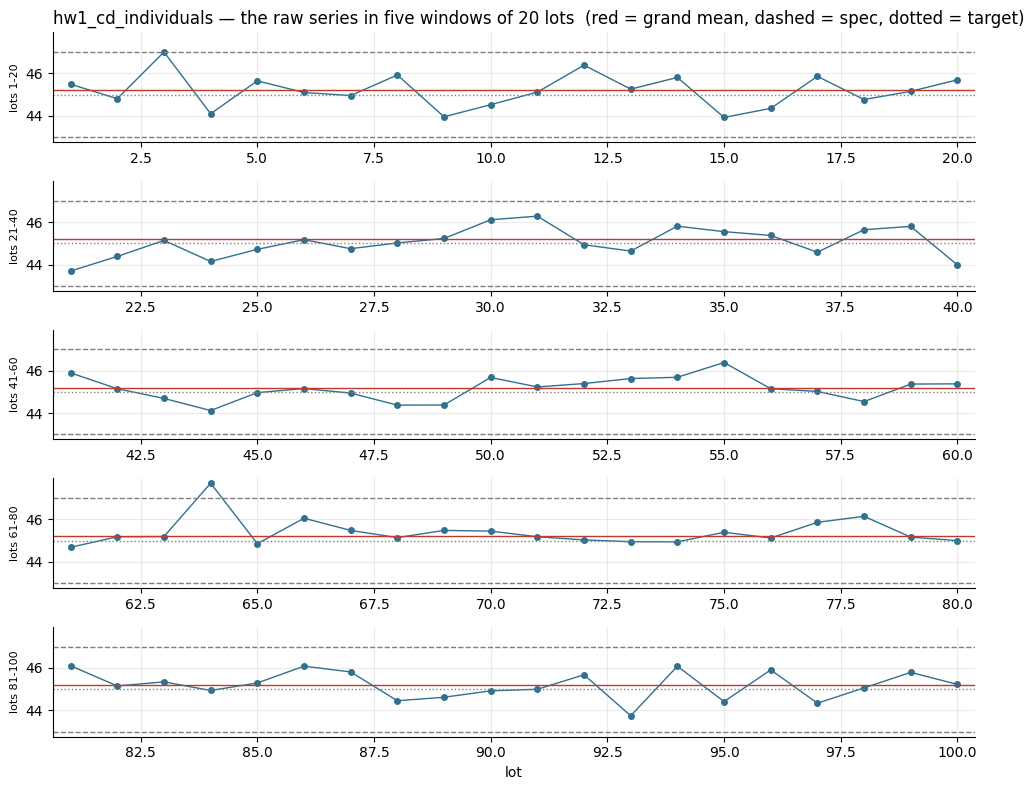

Same process throughout — no window behaves differently from the others by eye.


In [4]:
# ---------------------------------------------------------------- HW1 data
hw1_raw = pd.read_csv(DATA / "hw1_cd_individuals.csv")
print(f"hw1_cd_individuals.csv — {hw1_raw.shape[0]} rows x {hw1_raw.shape[1]} cols: "
      "one CD measurement per lot")
display(hw1_raw.head())
display(hw1_raw["cd_nm"].describe().to_frame().T)

# 100 lots in one strip is unreadable — split into five windows of 20, shared scale
fig, axes = plt.subplots(5, 1, figsize=(10, 8), sharey=True)
for k, ax in enumerate(axes):
    seg = hw1_raw.iloc[k * 20:(k + 1) * 20]
    ax.plot(seg["lot"], seg["cd_nm"], "o-", ms=4, lw=1, color=BLUE)
    for lim in (LSL, USL):
        ax.axhline(lim, color=GREY, ls="--", lw=1)
    ax.axhline(TGT, color=GREY, ls=":", lw=1)
    ax.axhline(hw1_raw["cd_nm"].mean(), color=RED, lw=1)
    ax.set_ylabel(f"lots {k*20+1}-{(k+1)*20}", fontsize=8)
    ax.margins(x=0.02)
axes[0].set_title("hw1_cd_individuals — the raw series in five windows of 20 lots  "
                  "(red = grand mean, dashed = spec, dotted = target)", loc="left")
axes[-1].set_xlabel("lot")
plt.tight_layout(); plt.show()
print("Same process throughout — no window behaves differently from the others by eye.")

## P1 — Characterise the process
*Data: `hw1_cd_individuals.csv`, 100 lots, one measurement each*

**The problem.** Using the 100 lots:

1. Compute the sample mean and standard deviation (n − 1).
2. Compute the distance from the mean to each specification limit in units of σ — the z
   values — and from those the ppm expected above USL and below LSL **separately**.
3. Report total ppm out of specification and the parametric yield.
4. State how far the process sits from target, and which side carries most of the loss.
5. Then ask what this yield figure actually covers, and how much you trust it.

In [5]:
hw1 = pd.read_csv(DATA / "hw1_cd_individuals.csv")
cd1 = hw1["cd_nm"].to_numpy()

m1, s1 = cd1.mean(), cd1.std(ddof=1)
zu, zl = (USL - m1) / s1, (m1 - LSL) / s1
ppm_hi = (1 - stats.norm.cdf(zu)) * 1e6
ppm_lo = (1 - stats.norm.cdf(zl)) * 1e6
ppm_tot = ppm_hi + ppm_lo
yield_pct = 100 * (1 - ppm_tot / 1e6)

p1 = pd.DataFrame({
    "quantity": ["n", "mean (nm)", "sigma, n-1 (nm)", "z to USL", "z to LSL",
                 "ppm above USL", "ppm below LSL", "total ppm", "parametric yield %"],
    "value": [len(cd1), m1, s1, zu, zl, ppm_hi, ppm_lo, ppm_tot, yield_pct]})
display(p1.style.format({"value": "{:,.3f}"}).hide(axis="index"))

print(f"\nppm high = (1 - Phi({zu:.3f})) x 1e6 = {ppm_hi/1e6:.6f} x 1e6")
print(f"the process runs {m1 - TGT:+.2f} nm off target, "
      f"so {100*ppm_hi/ppm_tot:.0f}% of the loss is on the upper side")

# what re-centring alone would buy
ppm_side = (1 - stats.norm.cdf((USL - TGT) / s1)) * 1e6
print(f"re-centred on {TGT} nm: {ppm_side:,.0f} ppm per side, {2*ppm_side:,.0f} ppm total "
      "— a recipe offset, not a project")

RESULTS.update({"hw1p1_mean": (m1, 45.200), "hw1p1_sigma": (s1, 0.680),
                "hw1p1_zu": (zu, 2.647), "hw1p1_zl": (zl, 3.235),
                "hw1p1_ppm": (ppm_tot, 4667.0)})

quantity,value
n,100.000
mean (nm),45.200
"sigma, n-1 (nm)",0.680
z to USL,2.647
z to LSL,3.235
ppm above USL,"4,058.452"
ppm below LSL,607.443
total ppm,"4,665.895"
parametric yield %,99.533



ppm high = (1 - Phi(2.647)) x 1e6 = 0.004058 x 1e6
the process runs +0.20 nm off target, so 87% of the loss is on the upper side
re-centred on 45.0 nm: 1,634 ppm per side, 3,269 ppm total — a recipe offset, not a project


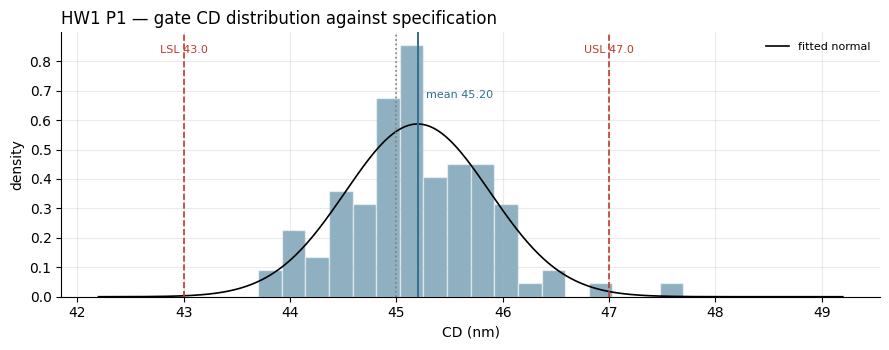

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(cd1, bins=18, color=BLUE, alpha=0.55, edgecolor="white", density=True)
grid = np.linspace(cd1.min() - 1.5, cd1.max() + 1.5, 400)
ax.plot(grid, stats.norm.pdf(grid, m1, s1), color="k", lw=1.2, label="fitted normal")
for lim, lab in ((LSL, "LSL 43.0"), (USL, "USL 47.0")):
    ax.axvline(lim, color=RED, ls="--", lw=1.2)
    ax.annotate(lab, (lim, ax.get_ylim()[1] * 0.92), ha="center", fontsize=8, color=RED)
ax.axvline(TGT, color=GREY, ls=":", lw=1.2)
ax.axvline(m1, color=BLUE, lw=1.4)
ax.annotate(f"mean {m1:.2f}", (m1, ax.get_ylim()[1] * 0.75), xytext=(6, 0),
            textcoords="offset points", fontsize=8, color=BLUE)
ax.set_title("HW1 P1 — gate CD distribution against specification", loc="left")
ax.set_xlabel("CD (nm)"); ax.set_ylabel("density"); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

### What this yield does and does not tell you

Two things limit it, and both matter more than the fourth decimal place:

- It is the yield contribution of **one parameter at one step**. Die yield is the product
  across hundreds of such parameters — 99.53% here is not 99.53% at the end of the line.
- It assumes normality, and it is a **tail** estimate, which is exactly where the normal
  assumption is least reliable. Quoting 4,667 ppm to four significant figures implies a
  precision the assumption cannot support.

The process is also off-centre. Re-centring on 45.0 nm alone would drop the loss to about
1,634 ppm per side — a recipe offset, not a capital project, and the cheapest improvement
available here.

## P2 — The variance budget, and the inversion

**The problem.** An engineering study on the same layer decomposes the CD variation into
three independent sources: σ_within = 2.4 nm, σ_wafer = 1.8 nm, σ_lot = 1.1 nm.

1. Compute σ_total. Show what adding the three σ values would have given, and why it is wrong.
2. Tabulate each source's variance and its share of the total.
3. **The inversion.** You are asked to reach σ_total = 2.5 nm by attacking **one** component.
   For each of the three, work out what that component would have to fall to — and flag any
   that cannot reach the target *even if driven to zero*.
4. Then decide what you would actually recommend, given that within-wafer reduction needs a
   new chamber kit and six months of qualification while lot-to-lot is a cheap incoming
   material change.

In [7]:
names = ["within-wafer", "wafer-to-wafer", "lot-to-lot"]
comp = np.array([2.4, 1.8, 1.1])
var = comp ** 2
sig_tot = np.sqrt(var.sum())

budget = pd.DataFrame({"source": names + ["TOTAL"],
                       "sigma (nm)": list(comp) + [sig_tot],
                       "variance (nm^2)": list(var) + [var.sum()],
                       "share": list(var / var.sum()) + [1.0]})
display(budget.style.format({"sigma (nm)": "{:.3f}", "variance (nm^2)": "{:.2f}",
                             "share": "{:.0%}"}).hide(axis="index"))

print(f"sigma_total = sqrt({var.sum():.2f}) = {sig_tot:.3f} nm")
print(f"naively adding the standard deviations gives {comp.sum():.1f} nm — variances add, "
      "standard deviations do not\n")

TARGET = 2.5
print(f"--- inversion: can any ONE component be attacked to reach {TARGET} nm? ---")
for i, nm in enumerate(names):
    others = np.delete(comp, i)
    floor = np.sqrt((others ** 2).sum())
    rem = TARGET ** 2 - (others ** 2).sum()
    if rem <= 0:
        print(f"  {nm:15s} ({comp[i]}): IMPOSSIBLE — the other two alone give {floor:.2f} nm")
    else:
        need = np.sqrt(rem)
        print(f"  {nm:15s} ({comp[i]}): must fall to {need:.2f} nm "
              f"— a {100*(1-need/comp[i]):.0f}% reduction. Achievable.")

RESULTS["hw1p2_total"] = (sig_tot, 3.195)

source,sigma (nm),variance (nm^2),share
within-wafer,2.400,5.76,56%
wafer-to-wafer,1.800,3.24,32%
lot-to-lot,1.100,1.21,12%
TOTAL,3.195,10.21,100%


sigma_total = sqrt(10.21) = 3.195 nm
naively adding the standard deviations gives 5.3 nm — variances add, standard deviations do not

--- inversion: can any ONE component be attacked to reach 2.5 nm? ---
  within-wafer    (2.4): must fall to 1.34 nm — a 44% reduction. Achievable.
  wafer-to-wafer  (1.8): IMPOSSIBLE — the other two alone give 2.64 nm
  lot-to-lot      (1.1): IMPOSSIBLE — the other two alone give 3.00 nm


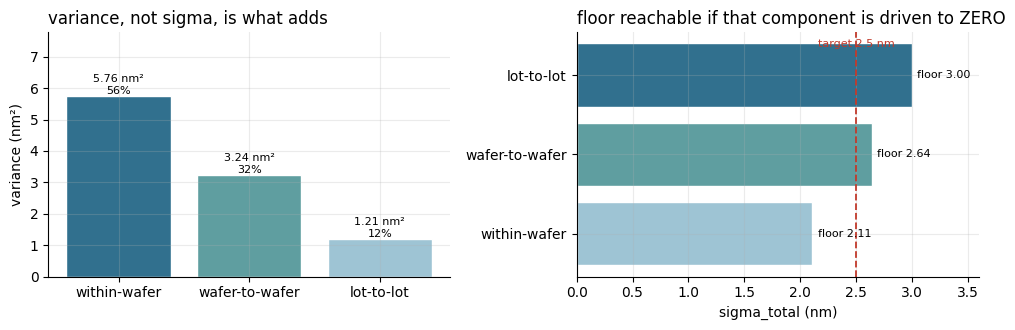

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

axes[0].bar(names, var, color=[BLUE, "#5f9ea0", "#9ec4d4"], edgecolor="white")
for i, v in enumerate(var):
    axes[0].annotate(f"{v:.2f} nm²\n{v/var.sum():.0%}", (i, v), ha="center",
                     va="bottom", fontsize=8)
axes[0].set_title("variance, not sigma, is what adds", loc="left")
axes[0].set_ylabel("variance (nm²)"); axes[0].set_ylim(0, var.max() * 1.35)

floors = [np.sqrt((np.delete(comp, i) ** 2).sum()) for i in range(3)]
axes[1].barh(names, floors, color=["#9ec4d4", "#5f9ea0", BLUE], edgecolor="white")
axes[1].axvline(TARGET, color=RED, ls="--", lw=1.3)
axes[1].annotate("target 2.5 nm", (TARGET, 2.35), color=RED, fontsize=8, ha="center")
for i, f in enumerate(floors):
    axes[1].annotate(f"floor {f:.2f}", (f, i), xytext=(4, 0), textcoords="offset points",
                     va="center", fontsize=8)
axes[1].set_title("floor reachable if that component is driven to ZERO", loc="left")
axes[1].set_xlabel("sigma_total (nm)"); axes[1].set_xlim(0, 3.6)
plt.tight_layout(); plt.show()

### The discovery

Two of the three terms cannot reach the target *even if driven to exactly zero*. Computing
the total and stopping is half the problem; the inversion is the other half.

### What to recommend

If within-wafer is expensive and lot-to-lot is cheap, the correct recommendation is still to
attack within-wafer — because the cheap fix cannot reach the target at any price. That is the
trap in this problem: effort spent on a small variance component is nearly wasted, and
"cheap" is irrelevant when the ceiling sits above the target.

## P3 — Sampling distribution

**The problem.** Using the mean and σ measured in P1:

1. Simulate 5,000 individual measurements and report their standard deviation.
2. Simulate 1,000 subgroups of n = 5 and report the standard deviation of the 1,000 subgroup
   **means**.
3. Compare the ratio of the two with √5, and account for any gap.
4. Then explain *why* averaging changes the spread, and what that implies for charting.

In [9]:
rng = np.random.default_rng(5)                     # same seed as gen_and_solve.py
indiv = rng.normal(m1, s1, 5000)
means5 = rng.normal(m1, s1, (1000, 5)).mean(axis=1)

s_ind, s_mean = indiv.std(ddof=1), means5.std(ddof=1)
ratio = s_ind / s_mean

print(f"sigma of individuals   = {s_ind:.4f}")
print(f"sigma of means of n=5  = {s_mean:.4f}")
print(f"ratio                  = {ratio:.3f}      sqrt(5) = {np.sqrt(5):.3f}")
print(f"gap = {100*abs(ratio-np.sqrt(5))/np.sqrt(5):.1f}% — sampling error in the "
      "simulation, not a discrepancy. Say so rather than hunt for a bug.")

RESULTS.update({"hw1p3_s_ind": (s_ind, 0.684), "hw1p3_s_mean": (s_mean, 0.292),
                "hw1p3_ratio": (ratio, 2.34)})

sigma of individuals   = 0.6840
sigma of means of n=5  = 0.2920
ratio                  = 2.343      sqrt(5) = 2.236
gap = 4.8% — sampling error in the simulation, not a discrepancy. Say so rather than hunt for a bug.


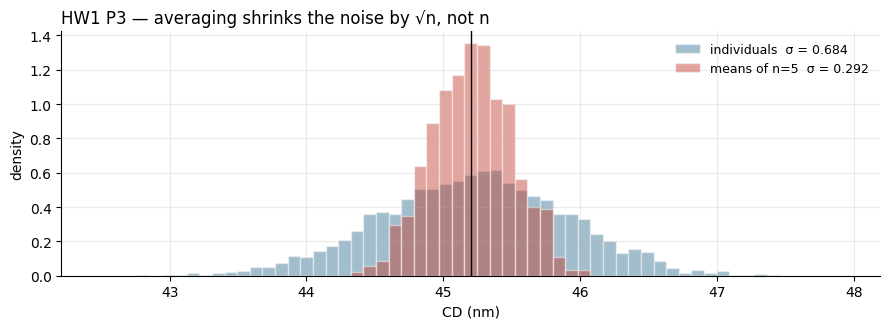

In [10]:
fig, ax = plt.subplots(figsize=(9, 3.4))
bins = np.linspace(m1 - 4 * s1, m1 + 4 * s1, 60)
ax.hist(indiv, bins=bins, density=True, color=BLUE, alpha=0.45,
        edgecolor="white", label=f"individuals  σ = {s_ind:.3f}")
ax.hist(means5, bins=bins, density=True, color=RED, alpha=0.45,
        edgecolor="white", label=f"means of n=5  σ = {s_mean:.3f}")
ax.axvline(m1, color="k", lw=1)
ax.set_title("HW1 P3 — averaging shrinks the noise by √n, not n", loc="left")
ax.set_xlabel("CD (nm)"); ax.set_ylabel("density"); ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

### Why this happens

Averaging cancels high and low draws, so the noise on the plotted statistic falls by √n —
while a real shift in the process mean is unaffected by averaging. Signal-to-noise therefore
improves by √n, which is exactly why X̄ limits are tighter than I-chart limits by that factor.
HW2 P2 verifies it numerically on real data.

Note it is **√n, not n**: going from one wafer to four halves the noise, but going from four
to sixteen only halves it again. That diminishing return is the sensitivity half of the
subgroup-size trade-off — the other half is the cost of measuring five wafers instead of one.

## P4 — The tampering simulation

**The problem.** A stable process, on target, σ = 1, 300 lots. Simulate two operating
policies on the **same** noise sequence:

- **Policy A** — leave it alone.
- **Policy B** — after every lot, adjust the process by the full observed deviation, to bring
  it back to target.

Report the standard deviation of the output under each, and the ratio between them. Compare
that ratio with the theoretical value for full correction. Then explain the mechanism, and
name a place it happens in a real fab.

> The correction must be **carried forward**: the adjustment made after lot *i* is still in
> effect when lot *i + 1* is produced. That is what the running `off` variable below does, and
> a simulation that leaves it out finds no difference between the two policies.

In [11]:
rng = np.random.default_rng(909)                   # same seed as gen_and_solve.py
noise = rng.normal(0, 1, 300)

free = noise.copy()                                # policy 1: leave it alone
adj = np.zeros(300)                                # policy 2: correct fully every lot
off = 0.0
for i in range(300):
    adj[i] = noise[i] + off                        # last correction is still in effect
    off -= adj[i]                                  # and we correct again on this lot

s_free, s_adj = free.std(ddof=1), adj.std(ddof=1)
print(f"leave it alone            sigma = {s_free:.3f}")
print(f"correct after every lot   sigma = {s_adj:.3f}   ({s_adj/s_free:.2f}x worse)")
print(f"theory: full correction gives Var = 2*sigma^2  ->  ratio sqrt(2) = {np.sqrt(2):.3f}")
print(f"\nDiscovery: the conscientious policy made the process "
      f"{100*(s_adj/s_free-1):.0f}% worse.")

RESULTS.update({"hw1p4_free": (s_free, 0.958), "hw1p4_adj": (s_adj, 1.401),
                "hw1p4_ratio": (s_adj / s_free, 1.46)})

leave it alone            sigma = 0.958
correct after every lot   sigma = 1.401   (1.46x worse)
theory: full correction gives Var = 2*sigma^2  ->  ratio sqrt(2) = 1.414

Discovery: the conscientious policy made the process 46% worse.


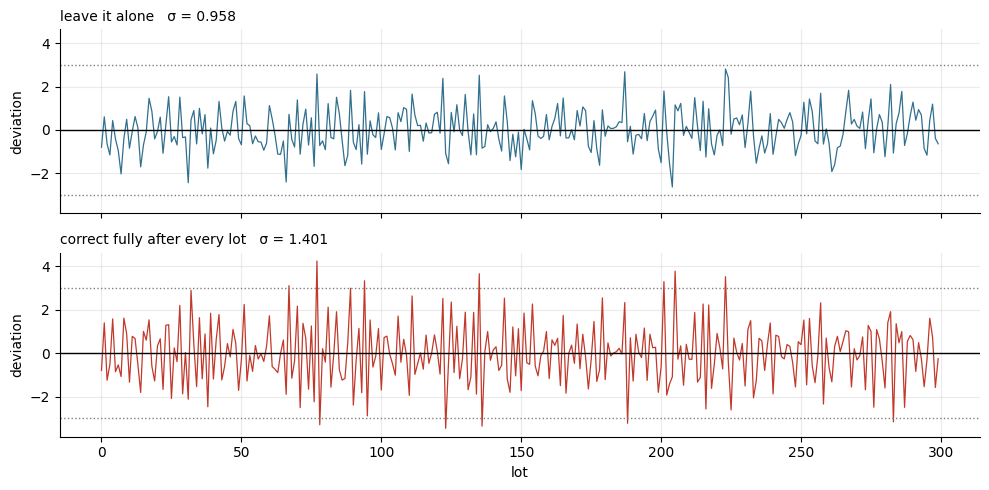

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, sharey=True)
for ax, y, lab, col in ((axes[0], free, "leave it alone", BLUE),
                        (axes[1], adj, "correct fully after every lot", RED)):
    ax.plot(y, lw=0.9, color=col)
    ax.axhline(0, color="k", lw=1)
    for k in (-3, 3):
        ax.axhline(k, color=GREY, ls=":", lw=1)
    ax.set_title(f"{lab}   σ = {y.std(ddof=1):.3f}", loc="left", fontsize=10)
    ax.set_ylabel("deviation")
axes[1].set_xlabel("lot")
plt.tight_layout(); plt.show()

### The mechanism

The observed deviation is noise, not a shift. The correction moves the process off target by
exactly that random amount, and the next lot's noise is added on top of the offset just
introduced. Errors accumulate instead of cancelling, and the variance doubles.

### Where this happens in a real fab

- An over-tuned run-to-run controller — λ → 1 is this simulation exactly (see HW3 P5)
- An operator adjusting a recipe after every out-of-target lot without a control chart
- Re-centring a process on a single measurement rather than on a subgroup average

Every individual correction looked justified at the time. That is what makes tampering hard
to argue against without this simulation in hand.

---
# HW2 — Charts and Capability

**What this set covers.** Building the two workhorse control charts and reading them
correctly; what changes when the subgroup size drops to one; what happens when the data
violates the independence assumption every chart rests on; and how to choose limits and rules
for a given economic context. Four problems.

### P1 — Build the X̄–R chart
*Data: `hw2_cd_subgroups.csv`*

For each lot compute the subgroup mean and range, then R̄ and X̄̄, and estimate the short-term
process σ as σ̂ = R̄/d₂(5). Build both charts — X̄ limits at X̄̄ ± A₂R̄, R limits at D₃R̄ and D₄R̄
— and plot them with out-of-control points marked. Apply run rules 1–5 using the σ of the
**plotted statistic** (for the X̄ chart, σ̂/√5), and report every violation as *chart, subgroup,
rule*. State which chart you read first and why the order matters here.

Then: at least one event in this data would never trigger Rule 1, however long the chart ran.
Which one, how did you find it, and how large is it relative to the specification? What does
that imply about running a chart with Rule 1 alone?

### P2 — The same data as individuals
*Data: `hw2_cd_subgroups.csv`, one wafer per lot*

Metrology throughput has been cut: you may now measure one wafer per lot, not five. Take a
single wafer column and build an I–MR chart — σ̂ = MR̄/d₂(2), limits at x̄ ± 3σ̂, MR chart UCL =
D₄(2)·MR̄. Compare this σ̂ with R̄/d₂(5) from P1 and say whether they should agree. Compare the
two charts' limit half-widths and take the ratio against √5. Check which Rule 1 violations from
P1 survive.

Then: explain the ratio from first principles. What detection capability did the metrology cut
cost you — name the specific event and its size against the tolerance. Was this a statistical
decision or a budget decision, and who made it?

### P3 — Autocorrelation
*Data: `hw2_etch_ar1.csv`*

Compute the sample lag-1 autocorrelation. Estimate σ two ways — from MR̄/1.128 and as the
ordinary standard deviation of all 200 values — and report the ratio. Build a naive
individuals chart from the MR̄-based σ̂, count the Rule 1 violations, and plot the series with
its limits and its autocorrelation function. No fault was planted in this data: the process is
stable and always returns to its mean.

Then: explain why a stable process produced that many alarms — specifically, what the
correlation does to MR̄ and therefore to the limits. A colleague proposes widening the limits
until the alarm rate looks reasonable. Explain why that is the wrong fix and give a better one.
At what point in the workflow should this have been caught?

### P4 — Limits and rules for two contexts

The same process, at the same capability, is run at two sites. An **automotive supplier**
ships to a tier-1 customer, so a defect that escapes can reach a vehicle; the line runs 24/7
and an investigation costs a few hours of engineering time. A **university research line**
runs ten wafers a week with no external customer; putting material on hold costs a week of
throughput.

For each site choose a control limit multiplier k and a set of run rules, compute the
in-control ARL₀ of your scheme, and convert it into a false-alarm rate in calendar time.

Then: justify both choices in terms of the relative cost of a false alarm (Type I) against a
missed shift (Type II) *at that site*. "Automotive needs higher quality" is not an argument —
both sites run the same process at the same capability.

### The data for HW2

**`hw2_cd_subgroups.csv` — 150 rows, 3 columns** *(P1, P2)*

| column | meaning |
|---|---|
| `lot` | lot number, 1–30, in time order |
| `wafer` | wafer position within the lot, 1–5 |
| `cd_nm` | gate CD in nanometres |

Thirty consecutive lots, five wafers measured per lot. The five wafers are the **rational
subgroup**: they were processed together, so the spread among them represents short-term,
common-cause variation only. The file is long format, one row per wafer, so
`df.pivot(index="lot", columns="wafer", values="cd_nm")` gives the 30 × 5 matrix the charts
need.

**`hw2_etch_ar1.csv` — 200 rows, 2 columns** *(P3)*

| column | meaning |
|---|---|
| `lot` | lot number, 1–200 |
| `etch_rate` | measured etch rate, Å/min, one value per lot |

Two hundred consecutive lots from a chamber whose etch rate depends on the state left behind by
the previous lot — a physically ordinary situation, and no fault was planted in the series.

**`hw2_probe_yield.csv` — 30 rows, 3 columns** *(Appendix)*

| column | meaning |
|---|---|
| `lot` | lot number, 1–30 |
| `die_tested` | die probed in that lot, varying between 150 and 900 |
| `die_failed` | die failing the probe test |

Attribute data — a count, not a measurement. The subgroup size changes lot to lot, which is
the point of the exercise.

hw2_cd_subgroups.csv — 150 rows = 30 lots x 5 wafers


,lot,wafer,cd_nm
0,1,1,44.6730
1,1,2,46.0600
2,1,3,44.6680
3,1,4,44.9860
4,1,5,45.1870
5,2,1,45.2370


pivoted to the 30 x 5 matrix the X-bar/R chart actually needs:


wafer,1,2,3,4,5
lot,,,,,
1,44.6730,46.0600,44.6680,44.9860,45.1870
2,45.2370,45.5270,45.0050,45.4910,44.3680
3,45.1670,45.0670,44.6710,44.9370,44.3770


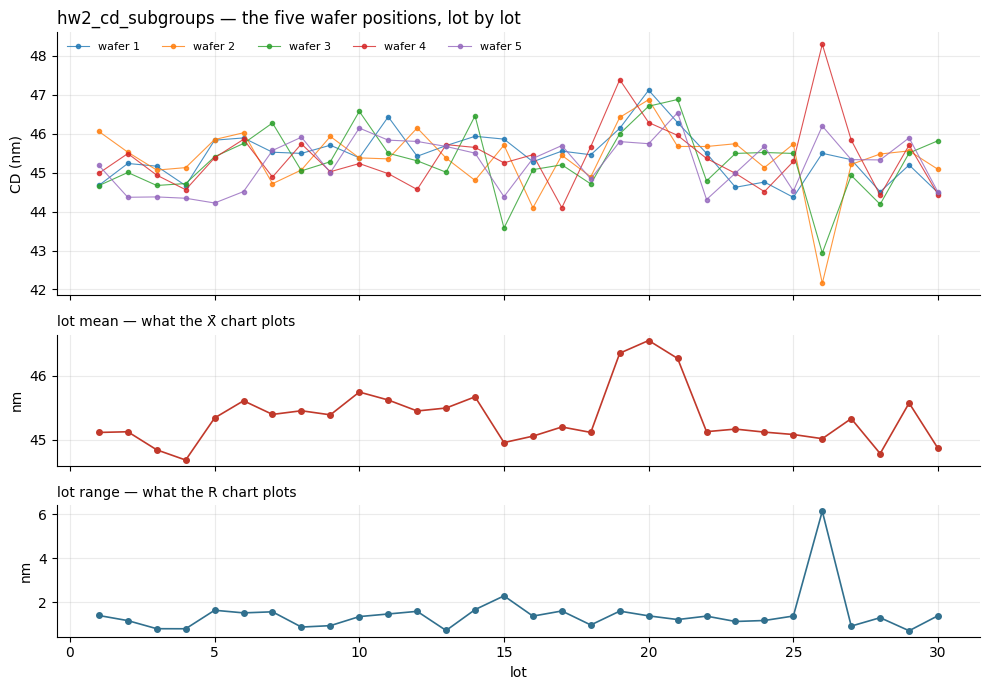

No single wafer position is systematically high or low — the five series are
interchangeable, which is what makes them a legitimate rational subgroup.


In [13]:
# ---------------------------------------------------------------- HW2 data
# --- P1, P2: 30 lots x 5 wafers, long format (one row per wafer)
d = pd.read_csv(DATA / "hw2_cd_subgroups.csv")
print(f"hw2_cd_subgroups.csv — {len(d)} rows = {d['lot'].nunique()} lots x "
      f"{d['wafer'].nunique()} wafers")
display(d.head(6))
print("pivoted to the 30 x 5 matrix the X-bar/R chart actually needs:")
wide = d.pivot(index="lot", columns="wafer", values="cd_nm")
display(wide.head(3))

# five wafer positions = five series measured on the same 30 lots
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1, 1]})
for wafer in wide.columns:
    axes[0].plot(wide.index, wide[wafer], "o-", ms=3, lw=0.8, alpha=0.8,
                 label=f"wafer {wafer}")
axes[0].set_title("hw2_cd_subgroups — the five wafer positions, lot by lot", loc="left")
axes[0].set_ylabel("CD (nm)"); axes[0].legend(frameon=False, fontsize=8, ncol=5)

axes[1].plot(wide.index, wide.mean(axis=1), "o-", ms=4, lw=1.2, color=RED)
axes[1].set_title("lot mean — what the X̄ chart plots", loc="left", fontsize=10)
axes[1].set_ylabel("nm")

axes[2].plot(wide.index, wide.max(axis=1) - wide.min(axis=1), "o-", ms=4, lw=1.2, color=BLUE)
axes[2].set_title("lot range — what the R chart plots", loc="left", fontsize=10)
axes[2].set_xlabel("lot"); axes[2].set_ylabel("nm")
plt.tight_layout(); plt.show()
print("No single wafer position is systematically high or low — the five series are")
print("interchangeable, which is what makes them a legitimate rational subgroup.")

hw2_etch_ar1.csv — 200 lots, no fault planted


,lot,etch_rate
0,1,"1,000.0000"
1,2,998.2150
2,3,995.0740
3,4,997.0020
4,5,994.8930


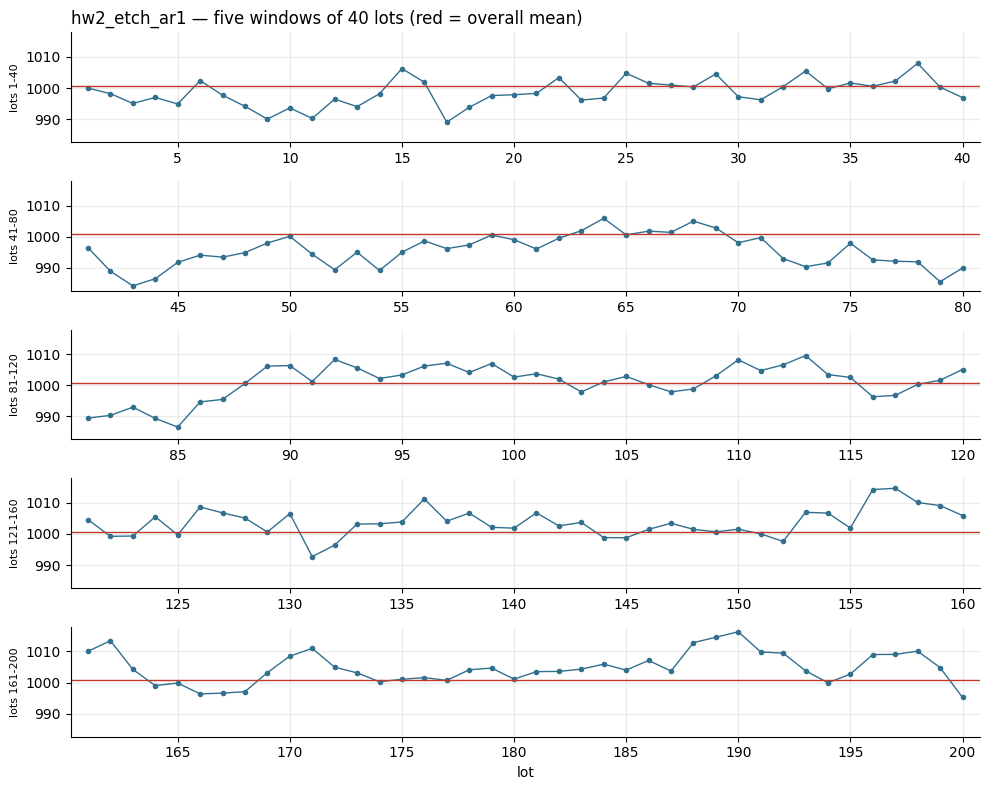

Each window drifts away and comes back. That is one process, not five.


In [14]:
# --- P3: 200 lots of an autocorrelated but perfectly healthy process
d = pd.read_csv(DATA / "hw2_etch_ar1.csv")
print(f"hw2_etch_ar1.csv — {len(d)} lots, no fault planted")
display(d.head())

# five windows of 40 lots, same scale: every window wanders, none is broken
fig, axes = plt.subplots(5, 1, figsize=(10, 8), sharey=True)
for k, ax in enumerate(axes):
    seg = d.iloc[k * 40:(k + 1) * 40]
    ax.plot(seg["lot"], seg["etch_rate"], "o-", ms=3, lw=1, color=BLUE)
    ax.axhline(d["etch_rate"].mean(), color=RED, lw=1)
    ax.set_ylabel(f"lots {k*40+1}-{(k+1)*40}", fontsize=8)
    ax.margins(x=0.02)
axes[0].set_title("hw2_etch_ar1 — five windows of 40 lots (red = overall mean)", loc="left")
axes[-1].set_xlabel("lot")
plt.tight_layout(); plt.show()
print("Each window drifts away and comes back. That is one process, not five.")

hw2_probe_yield.csv — 30 lots, die tested ranges 152 to 879


,lot,die_tested,die_failed
0,1,609,25
1,2,338,14
2,3,879,52
3,4,860,35
4,5,198,13


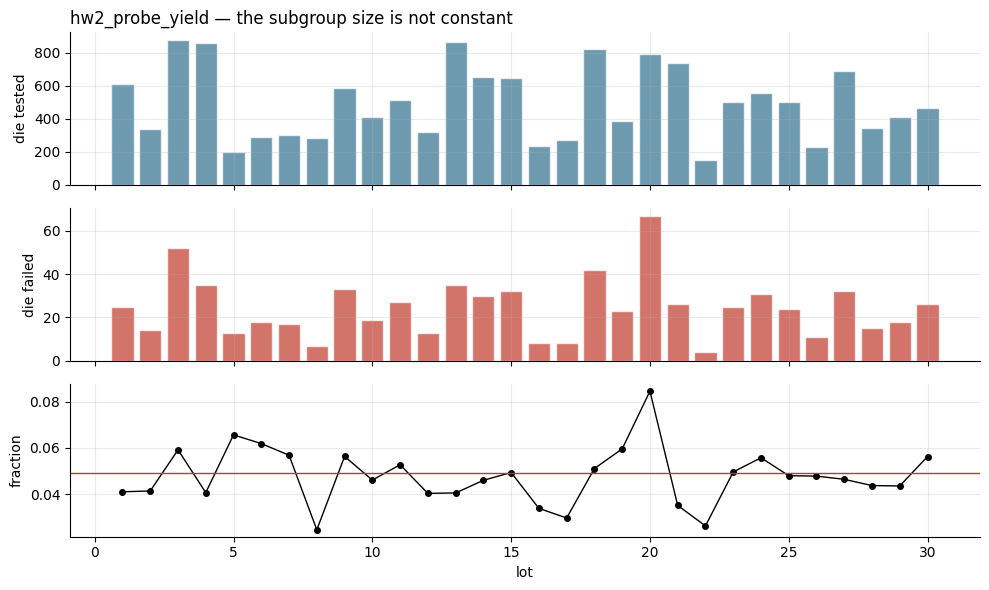

The fraction is the ratio of the two series above it — and because the denominator
changes lot to lot, so does the width of the limits in the p chart.


In [15]:
# --- Appendix: attribute data, subgroup size varies lot to lot
d = pd.read_csv(DATA / "hw2_probe_yield.csv")
print(f"hw2_probe_yield.csv — {len(d)} lots, die tested ranges "
      f"{d['die_tested'].min()} to {d['die_tested'].max()}")
display(d.head())

# three series here: the count tested, the count failed, and the fraction
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
axes[0].bar(d["lot"], d["die_tested"], color=BLUE, alpha=0.7, edgecolor="white")
axes[0].set_ylabel("die tested"); axes[0].set_title(
    "hw2_probe_yield — the subgroup size is not constant", loc="left")
axes[1].bar(d["lot"], d["die_failed"], color=RED, alpha=0.7, edgecolor="white")
axes[1].set_ylabel("die failed")
axes[2].plot(d["lot"], d["die_failed"] / d["die_tested"], "o-", ms=4, lw=1, color="k")
axes[2].axhline(d["die_failed"].sum() / d["die_tested"].sum(), color=RED, lw=1)
axes[2].set_ylabel("fraction"); axes[2].set_xlabel("lot")
plt.tight_layout(); plt.show()
print("The fraction is the ratio of the two series above it — and because the denominator")
print("changes lot to lot, so does the width of the limits in the p chart.")

## P1 — Build the X̄–R chart
*Data: `hw2_cd_subgroups.csv`, 30 lots × 5 wafers*

**The problem.**

1. For each lot compute the subgroup mean and range, then R̄ and X̄̄.
2. Estimate the short-term process σ as σ̂ = R̄ / d₂(5).
3. Build both charts — X̄ limits at X̄̄ ± A₂R̄, R limits at D₃R̄ and D₄R̄ — and plot them with
   the out-of-control points marked.
4. Apply run rules 1–5 using the σ of the **plotted statistic** (for the X̄ chart that is
   σ̂/√5), and report every violation as *chart, subgroup, rule*.
5. Identify which event would never trigger Rule 1, however long the chart ran.

Read the R chart first: the X̄ limits are computed from R̄, so an unstable spread invalidates
them.

In [16]:
sub = pd.read_csv(DATA / "hw2_cd_subgroups.csv")
CD = sub.pivot(index="lot", columns="wafer", values="cd_nm").to_numpy()   # 30 x 5
K, n = CD.shape

xbar = CD.mean(axis=1)
Rng = CD.max(axis=1) - CD.min(axis=1)
Xbb, Rbar = xbar.mean(), Rng.mean()
sig_hat = Rbar / D2[5]                      # short-term sigma from the ranges

UCLx, LCLx = Xbb + A2[5] * Rbar, Xbb - A2[5] * Rbar
UCLr, LCLr = D4[5] * Rbar, D3[5] * Rbar

print(f"K = {K} subgroups of n = {n}")
print(f"R-bar          = {Rbar:.3f} nm")
print(f"sigma-hat      = R-bar/d2 = {Rbar:.3f}/{D2[5]} = {sig_hat:.4f} nm")
print(f"X-double-bar   = {Xbb:.3f} nm")
print(f"A2*R-bar       = {A2[5]} x {Rbar:.3f} = {A2[5]*Rbar:.3f}")
print(f"X-bar limits   = {LCLx:.3f} to {UCLx:.3f} nm")
print(f"R limits       = {LCLr:.3f} to {UCLr:.3f} nm   (D4*R-bar)")

RESULTS.update({"hw2p1_Rbar": (Rbar, 1.440), "hw2p1_sigma": (sig_hat, 0.619),
                "hw2p1_Xbb": (Xbb, 45.350), "hw2p1_UCLx": (UCLx, 46.181),
                "hw2p1_LCLx": (LCLx, 44.519), "hw2p1_UCLr": (UCLr, 3.044)})

K = 30 subgroups of n = 5
R-bar          = 1.440 nm
sigma-hat      = R-bar/d2 = 1.440/2.326 = 0.6191 nm
X-double-bar   = 45.350 nm
A2*R-bar       = 0.577 x 1.440 = 0.831
X-bar limits   = 44.519 to 46.181 nm
R limits       = 0.000 to 3.044 nm   (D4*R-bar)


In [17]:
sig_xbar = sig_hat / np.sqrt(n)                 # sigma of the plotted statistic
oo_r = [int(i) for i in np.where((Rng > UCLr) | (Rng < LCLr))[0] + 1]
rules_x = run_rules(xbar, Xbb, sig_xbar)

print("R chart, rule 1 :", oo_r)
print("X-bar chart:")
for k, v in rules_x.items():
    if v:
        print(f"   rule {k}: {v}")

events = pd.DataFrame([
    ("R",     "26",       1, "within-lot spread tripled, that lot only"),
    ("X-bar", "19,20,21", 1, "+1.30 nm step shift"),
    ("X-bar", "14",       4, "+0.35 nm sustained shift, lots 5-14 (nine on one side)"),
    ("X-bar", "20,21",    2, "same step — two of three in zone A"),
], columns=["chart", "subgroup", "rule", "what was planted"])
display(events.style.hide(axis="index"))
print("Three distinct events — reading only '19, 20, 21 are out' catches one of them.")
print("Note the pair at subgroup 26: the R chart fires and the X-bar chart is silent there.")
print("That combination is the reason for the read-R-first rule.")

RESULTS.update({"hw2p1_r1_x": (len(rules_x['1']), 3), "hw2p1_r1_R": (len(oo_r), 1)})

R chart, rule 1 : [26]
X-bar chart:
   rule 1: [19, 20, 21]
   rule 2: [20, 21]
   rule 4: [14]


chart,subgroup,rule,what was planted
R,26,1,"within-lot spread tripled, that lot only"
X-bar,"19,20,21",1,+1.30 nm step shift
X-bar,14,4,"+0.35 nm sustained shift, lots 5-14 (nine on one side)"
X-bar,"20,21",2,same step — two of three in zone A


Three distinct events — reading only '19, 20, 21 are out' catches one of them.
Note the pair at subgroup 26: the R chart fires and the X-bar chart is silent there.
That combination is the reason for the read-R-first rule.


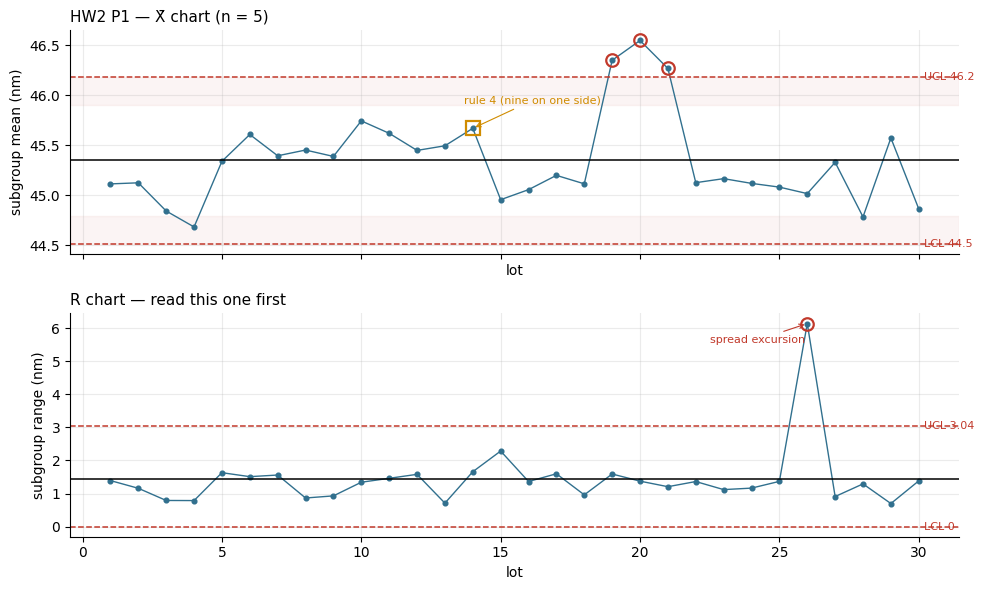

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
chart(xbar, Xbb, LCLx, UCLx, "HW2 P1 — X̄ chart (n = 5)", "subgroup mean (nm)",
      viol=rules_x["1"], ax=axes[0])
for i in rules_x["4"]:
    axes[0].plot(i, xbar[i - 1], "s", ms=10, mfc="none", mec="#d08c00", mew=1.6)
axes[0].axhspan(Xbb + 2 * sig_xbar, UCLx, color=RED, alpha=0.05)
axes[0].axhspan(LCLx, Xbb - 2 * sig_xbar, color=RED, alpha=0.05)
axes[0].annotate("rule 4 (nine on one side)", (14, xbar[13]), xytext=(-6, 18),
                 textcoords="offset points", fontsize=8, color="#d08c00",
                 arrowprops=dict(arrowstyle="->", color="#d08c00", lw=0.8))

chart(Rng, Rbar, LCLr, UCLr, "R chart — read this one first", "subgroup range (nm)",
      viol=oo_r, ax=axes[1])
axes[1].annotate("spread excursion", (26, Rng[25]), xytext=(-70, -14),
                 textcoords="offset points", fontsize=8, color=RED,
                 arrowprops=dict(arrowstyle="->", color=RED, lw=0.8))
plt.tight_layout(); plt.show()

### The event Rule 1 cannot see

The **+0.35 nm shift over lots 5–14**. It is about 1.3σ of the subgroup mean, so no single
point comes close to a limit — but ten consecutive points sit on the same side, which Rule 4
catches at subgroup 14.

Operationally: a shift of this size is roughly a third of the total specification margin, and
on a Rule-1-only chart it would run indefinitely. That is the concrete case for enabling
Rule 4, and it is what P4 asks you to price.

## P2 — The same data as individuals

**The problem.** Metrology throughput has been cut: you may now measure **one wafer per lot**,
not five. Take a single wafer column from the same file and treat it as an individuals series.

1. Build an I–MR chart: σ̂ = MR̄ / d₂(2), limits at x̄ ± 3σ̂, MR chart UCL = D₄(2)·MR̄.
2. Compare this σ̂ with R̄/d₂(5) from P1. Should they agree?
3. Compare the two charts' **limit half-widths** and take the ratio. Compare it with √5.
4. Check which Rule 1 violations from P1 survive here.
5. Then say what the metrology cut actually cost you, in terms of a specific event.

Any single wafer column is a legitimate choice and gives slightly different numbers. The cell
below picks the column whose MR̄-based σ̂ is closest to the within-subgroup σ̂ — wafer 5 — so
that the √n comparison is not swamped by sampling error in a 29-point moving-range estimate.

In [19]:
wcol = int(np.argmin([abs(sigma_from_mr(CD[:, j]) - sig_hat) for j in range(n)]))
ind = CD[:, wcol]
print(f"[using wafer {wcol+1} of each lot for the individuals chart]\n")

MRbar = np.abs(np.diff(ind)).mean()
sig_i = MRbar / D2[2]
CLi = ind.mean()
UCLi, LCLi = CLi + 3 * sig_i, CLi - 3 * sig_i
oo_i = [int(i) for i in np.where((ind > UCLi) | (ind < LCLi))[0] + 1]
rules_i = run_rules(ind, CLi, sig_i)

half_x, half_i = 3 * sig_xbar, 3 * sig_i
cmp_tbl = pd.DataFrame({
    "quantity": ["sigma-hat", "source of sigma-hat", "limit half-width",
                 "centre line", "limits", "rule 1 violations"],
    "X-bar chart (n=5)": [f"{sig_hat:.3f}", "R-bar/d2(5)", f"{half_x:.3f}",
                          f"{Xbb:.3f}", f"{LCLx:.3f} - {UCLx:.3f}",
                          str(rules_x["1"])],
    "I chart (n=1)": [f"{sig_i:.3f}", f"MR-bar/1.128 (MR-bar={MRbar:.3f})",
                      f"{half_i:.3f}", f"{CLi:.3f}", f"{LCLi:.3f} - {UCLi:.3f}",
                      str(oo_i) if oo_i else "none"]})
display(cmp_tbl.style.hide(axis="index"))

print(f"ratio of half-widths = {half_i/half_x:.2f}      sqrt(5) = {np.sqrt(5):.3f}")
print(f"MR chart UCL = D4(2)*MR-bar = {D4[2]*MRbar:.3f}")
print("\nThe two sigma-hat estimates agree closely — both estimate the same within-process")
print("short-term variation. The LIMITS differ by sqrt(5) purely because of what is plotted.")
print(f"Consequence: the step shift at lots 19-21, which broke rule 1 three times on the")
print(f"X-bar chart, produces {len(oo_i)} rule 1 violations on the individuals chart.")
print("Run rules that do fire on the I chart:", {k: v for k, v in rules_i.items() if v})

RESULTS.update({"hw2p2_sigma": (sig_i, 0.603), "hw2p2_MRbar": (MRbar, 0.680),
                "hw2p2_half": (half_i, 1.810), "hw2p2_ratio": (half_i / half_x, 2.18),
                "hw2p2_viol": (len(oo_i), 0)})

[using wafer 5 of each lot for the individuals chart]



quantity,X-bar chart (n=5),I chart (n=1)
sigma-hat,0.619,0.603
source of sigma-hat,R-bar/d2(5),MR-bar/1.128 (MR-bar=0.680)
limit half-width,0.831,1.810
centre line,45.350,45.253
limits,44.519 - 46.181,43.443 - 47.062
rule 1 violations,"[19, 20, 21]",none


ratio of half-widths = 2.18      sqrt(5) = 2.236
MR chart UCL = D4(2)*MR-bar = 2.223

The two sigma-hat estimates agree closely — both estimate the same within-process
short-term variation. The LIMITS differ by sqrt(5) purely because of what is plotted.
Consequence: the step shift at lots 19-21, which broke rule 1 three times on the
X-bar chart, produces 0 rule 1 violations on the individuals chart.
Run rules that do fire on the I chart: {'3': [5, 6], '5': [15]}


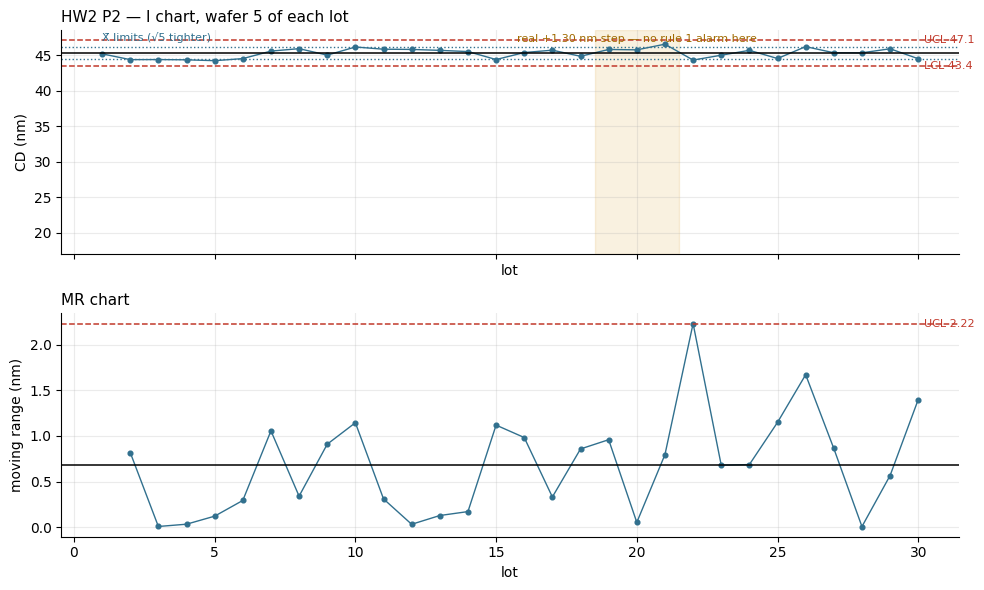

In [20]:
MR = np.abs(np.diff(ind))
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
chart(ind, CLi, LCLi, UCLi, f"HW2 P2 — I chart, wafer {wcol+1} of each lot",
      "CD (nm)", viol=oo_i, ax=axes[0])
axes[0].axhspan(19 - 0.5, 21 + 0.5, xmin=0, xmax=0, color="none")   # keep axis limits
axes[0].axvspan(18.5, 21.5, color="#d08c00", alpha=0.12)
axes[0].annotate("real +1.30 nm step — no rule 1 alarm here", (20, ind.max()),
                 ha="center", va="bottom", fontsize=8, color="#a06a00")
# the X-bar limits drawn on the same scale, for the sqrt(5) comparison
for lim in (UCLx, LCLx):
    axes[0].axhline(lim, color=BLUE, ls=":", lw=1)
axes[0].annotate("X̄ limits (√5 tighter)", (1, UCLx), xytext=(0, 4),
                 textcoords="offset points", fontsize=8, color=BLUE)

chart(MR, MRbar, None, D4[2] * MRbar, "MR chart", "moving range (nm)",
      x=np.arange(2, K + 1), ax=axes[1])
plt.tight_layout(); plt.show()

### What the metrology cut bought and cost

- **The √n explanation:** σ_x̄ = σ/√n, so limits on the mean are √5 ≈ 2.24 times tighter than
  limits on individuals drawn from the same process.
- **What was given up:** a real, sustained 1.3 nm shift — about a third of the tolerance —
  went undetected by Rule 1.
- **The framing:** this was not a statistical choice. A metrology budget decided your
  detection capability on your behalf, and nobody wrote it down as such.

Run rules become *more* important when n = 1, precisely because Rule 1 is carrying much less
of the load.

## P3 — Autocorrelation
*Data: `hw2_etch_ar1.csv`, 200 lots, AR(1) with φ = 0.8, **no fault planted***

**The problem.**

1. Compute the sample lag-1 autocorrelation of the etch rate.
2. Estimate σ two ways — from MR̄/1.128, and as the ordinary standard deviation of all 200
   values — and report the ratio.
3. Build a naive individuals chart from the MR̄-based σ̂ and count the Rule 1 violations.
4. Plot the series with its limits, and the autocorrelation function.
5. Then explain how a stable process produced that many alarms, and what the right fix is.

In [21]:
ar = pd.read_csv(DATA / "hw2_etch_ar1.csv")
y = ar["etch_rate"].to_numpy()

lag1 = np.corrcoef(y[:-1], y[1:])[0, 1]
s_mr = sigma_from_mr(y)
s_all = y.std(ddof=1)
cl_ar = y.mean()
UCL_ar, LCL_ar = cl_ar + 3 * s_mr, cl_ar - 3 * s_mr
viol_ar = [int(i) for i in np.where((y > UCL_ar) | (y < LCL_ar))[0] + 1]

print(f"sample lag-1 correlation = {lag1:.3f}")
print(f"sigma-hat from MR-bar/1.128 = {s_mr:.3f}")
print(f"sigma from all 200 values   = {s_all:.3f}   (ratio {s_all/s_mr:.2f}x)")
print(f"theoretical stationary sigma = 4.0/sqrt(1-0.8^2) = {4.0/np.sqrt(1-0.64):.2f}")
print(f"I-chart limits {LCL_ar:.1f} to {UCL_ar:.1f}  ->  {len(viol_ar)} violations in 200 lots")
print("\nNothing is wrong with this process. It is stationary, it always returns,")
print("and 26 lots were flagged.")

RESULTS.update({"hw2p3_lag1": (lag1, 0.740), "hw2p3_smr": (s_mr, 3.087),
                "hw2p3_sall": (s_all, 6.012), "hw2p3_viol": (len(viol_ar), 26)})

sample lag-1 correlation = 0.740
sigma-hat from MR-bar/1.128 = 3.087
sigma from all 200 values   = 6.012   (ratio 1.95x)
theoretical stationary sigma = 4.0/sqrt(1-0.8^2) = 6.67
I-chart limits 991.5 to 1010.0  ->  26 violations in 200 lots

Nothing is wrong with this process. It is stationary, it always returns,
and 26 lots were flagged.


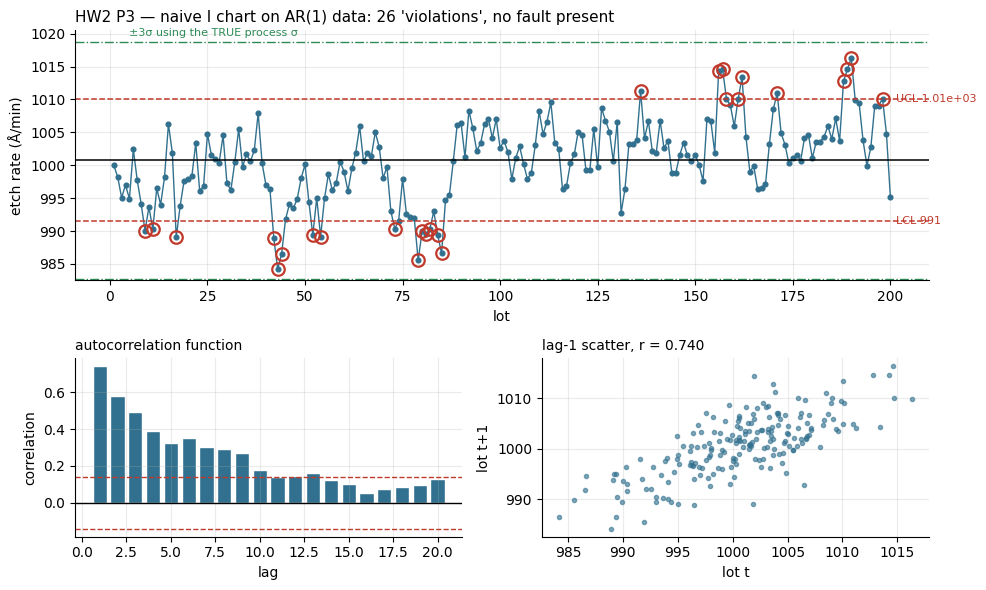

In [22]:
fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(2, 2, height_ratios=[1.4, 1])
ax0 = fig.add_subplot(gs[0, :])
chart(y, cl_ar, LCL_ar, UCL_ar,
      f"HW2 P3 — naive I chart on AR(1) data: {len(viol_ar)} 'violations', no fault present",
      "etch rate (Å/min)", viol=viol_ar, ax=ax0)
ax0.axhline(cl_ar + 3 * s_all, color="#2e8b57", ls="-.", lw=1)
ax0.axhline(cl_ar - 3 * s_all, color="#2e8b57", ls="-.", lw=1)
ax0.annotate("±3σ using the TRUE process σ", (5, cl_ar + 3 * s_all), xytext=(0, 4),
             textcoords="offset points", fontsize=8, color="#2e8b57")

ax1 = fig.add_subplot(gs[1, 0])
lags = np.arange(1, 21)
acf = [np.corrcoef(y[:-k], y[k:])[0, 1] for k in lags]
ax1.bar(lags, acf, color=BLUE, edgecolor="white")
ax1.axhline(0, color="k", lw=1)
ax1.axhline(1.96 / np.sqrt(len(y)), color=RED, ls="--", lw=1)
ax1.axhline(-1.96 / np.sqrt(len(y)), color=RED, ls="--", lw=1)
ax1.set_title("autocorrelation function", loc="left", fontsize=10)
ax1.set_xlabel("lag"); ax1.set_ylabel("correlation")

ax2 = fig.add_subplot(gs[1, 1])
ax2.plot(y[:-1], y[1:], "o", ms=3, color=BLUE, alpha=0.6)
ax2.set_title(f"lag-1 scatter, r = {lag1:.3f}", loc="left", fontsize=10)
ax2.set_xlabel("lot t"); ax2.set_ylabel("lot t+1")
plt.tight_layout(); plt.show()

### Why the chart fires

Consecutive values are close together *because they are correlated*, so the moving range is
small, so σ̂ = MR̄/1.128 is roughly half the true process σ. The limits are therefore about
half as wide as they should be, and the process's normal wandering crosses them repeatedly.

### Why widening the limits is the wrong fix

Widening treats the symptom. It restores a sensible false-alarm rate only by discarding
sensitivity you have already paid for, and it leaves you with a chart whose stated
false-alarm rate is fiction.

Better answers, in order of preference:

1. Model the correlation and chart the **residual** — this is HW3 P3, and the general
   principle from Lecture 3
2. Use a chart designed for autocorrelated data — EWMA on the residual, or a time-series
   model with control limits on the innovations
3. Subsample far enough apart that consecutive observations are effectively independent —
   crude, and it throws away data

The real lesson is about sequence: independence should be checked *before* the chart is
built, not after its alarm rate turns out to be absurd.

## P4 — Limits and rules for two contexts

**The problem.** The same process, at the same capability, is run at two sites:

- **An automotive supplier.** Parts ship to a tier-1 customer; a defect that escapes can reach
  a vehicle. The line runs 24/7 and an investigation costs a few hours of engineering time.
- **A university research line.** Ten wafers a week, no external customer, results feed a
  paper. Putting material on hold costs a week of throughput.

For each site, choose a control limit multiplier k and a set of run rules, compute the
in-control ARL₀ of your scheme, and convert it into a false-alarm rate in calendar time. Then
justify both choices.

There is no single correct answer here — the reasoning and the arithmetic are the content.
ARL₀ below combines independent per-rule alarm probabilities, the standard approximation;
simulation gives slightly different numbers.

In [23]:
def arl0(k, rules=()):
    "In-control ARL from combined per-rule alarm probabilities (both sides)."
    p = 2 * (1 - stats.norm.cdf(k))                       # rule 1
    if "2" in rules:
        pa = 1 - stats.norm.cdf(2)
        p += 2 * 3 * pa ** 2 * (1 - pa)                   # two of three beyond 2 sigma
    if "3" in rules:
        pb = 1 - stats.norm.cdf(1)
        p += 2 * 5 * pb ** 4 * (1 - pb)                   # four of five beyond 1 sigma
    if "4" in rules:
        p += 2 * 0.5 ** 9                                 # nine on one side
    if "5" in rules:
        p += 2 / math.factorial(6)                        # six steadily trending
    return 1 / p


schemes = [("k = 3, rule 1 only", 3.0, ()),
           ("k = 3, rules 1 + 4", 3.0, ("4",)),
           ("k = 3, rules 1+2+3+4+5", 3.0, ("2", "3", "4", "5")),
           ("k = 3.5, rule 1 only", 3.5, ())]
arl = pd.DataFrame([(lab, arl0(k, r)) for lab, k, r in schemes], columns=["scheme", "ARL0"])
display(arl.style.format({"ARL0": "{:,.0f}"}).hide(axis="index"))

print("A defensible answer")
print("-------------------")
print("Automotive supplier : k = 3, rules 1+2+3+4+5   ARL0 ~ "
      f"{arl0(3.0, ('2','3','4','5')):.0f}")
print("   Charted daily that is roughly one false alarm every two months per chart.")
print("   A missed shift risks an escape and an escape risks a recall — an unbounded cost")
print("   against a bounded investigation cost. Buy sensitivity, pay in nuisance alarms.\n")
print(f"Research line       : k = 3 or 3.5, rule 1 only    ARL0 ~ {arl0(3.0):.0f} to "
      f"{arl0(3.5):,.0f}")
print("   At 10 wafers per week a hold costs a week of throughput, and with no external")
print("   customer the escape cost is near zero. Type I error dominates. Widen and simplify.")

RESULTS.update({"hw2p4_arl_r1": (arl0(3.0), 370), "hw2p4_arl_r14": (arl0(3.0, ("4",)), 151),
                "hw2p4_arl_all": (arl0(3.0, ("2", "3", "4", "5")), 56),
                "hw2p4_arl_35": (arl0(3.5), 2149)})

scheme,ARL0
"k = 3, rule 1 only",370
"k = 3, rules 1 + 4",151
"k = 3, rules 1+2+3+4+5",56
"k = 3.5, rule 1 only","2,149"


A defensible answer
-------------------
Automotive supplier : k = 3, rules 1+2+3+4+5   ARL0 ~ 56
   Charted daily that is roughly one false alarm every two months per chart.
   A missed shift risks an escape and an escape risks a recall — an unbounded cost
   against a bounded investigation cost. Buy sensitivity, pay in nuisance alarms.

Research line       : k = 3 or 3.5, rule 1 only    ARL0 ~ 370 to 2,149
   At 10 wafers per week a hold costs a week of throughput, and with no external
   customer the escape cost is near zero. Type I error dominates. Widen and simplify.


### The point of the comparison

The choice has to be argued as the *relative cost of Type I versus Type II error at that
site* — not as "automotive needs higher quality." Both sites are running the same process at
the same capability. What differs is the consequence of each kind of error: an escape that
reaches a vehicle is an unbounded cost, while a hold on a research line costs a week of
throughput and nothing else.

Choosing the same scheme for both sites, or justifying the difference by product quality
rather than error economics, misses the whole exercise.

---
# HW3 — Measurement, Cases, and Multivariate

**What this set covers.** Whether your measurement system is good enough to support the
conclusions you have been drawing from it; how to chart a process with a known deterministic
component; how to monitor many correlated sensors at once; and what a feedback controller hides
from you. Four problems plus a bonus.

### P1 — Gauge R&R
*Data: `hw3_gauge_study_A.csv`, `hw3_gauge_study_B.csv`*

For each study, by two-way ANOVA with interaction (reproducibility = tool + interaction),
report σ for repeatability, reproducibility, combined gauge R&R, part-to-part and total. Then
compute the three standard acceptance metrics — %R&R against tolerance (6σ_R&R / (USL − LSL)),
%R&R against total variation (σ_R&R / σ_total), and the number of distinct categories
(ndc = 1.41 σ_part / σ_R&R) — and give the verdict for each, against < 10% acceptable,
10–30% conditional, > 30% unacceptable, ndc ≥ 5 required.

One of the two studies produces metrics that disagree with each other.

Then: why do they disagree, given that they describe the same gauge? Which metric would you use
to decide whether measured material can be dispositioned against specification, and which to
decide whether the gauge can support a process-improvement study? And if a variation-reduction
project succeeds, what happens to %R&R against total variation — is that a real change in the
gauge?

### P2 — Correct your own capability number

The HW2 subgroup data was measured on CD-SEM #1, the tool characterised by Study A. So the σ̂
computed in HW2 P1 is not the process: it is the process **and** the gauge, added in
quadrature.

Compute capability as measured — Cp, Cpk and ppm out of specification — from the HW2 P1 σ̂ and
X̄̄. Then remove the gauge, σ²_process = σ²_observed − σ²_gauge, and recompute all three.
Tabulate before and after, and note where Cpk lands relative to 1.0.

Then: does the corrected number change what you would recommend? A colleague reads your table
and proposes cancelling a planned chamber upgrade on the grounds that the process is better
than it looked. Is that the right call? What has to happen first, and why is it on the critical
path rather than merely a reporting issue?

### P3 — Residual charting
*Data: `hw3_etch_seasoning.csv`*

The chamber seasons as it runs: the etch rate drifts predictably between preventive
maintenances and resets at each one. Process engineering gives the expected behaviour as
`1000 − 0.42 × wafers_since_pm`, and `wafers_since_pm` is supplied in the file.

Build a naive individuals chart on the raw etch rate and count the violations. Then form the
residual, `etch_rate − expected`, and chart that instead, estimating its centre line and σ̂
from an early window you are willing to call clean. Compare the two charts: violations before
and after lot 76, totals, and the two σ̂ estimates. Report the first residual violation and the
delay between it and the apparent onset of the change.

Then: state the general principle in one sentence — what a control chart should be built on,
and what an alarm then means. Give an example of a signal from your own research or work with a
known deterministic component: what would you model, and what would be left to chart?

### P4 — Multivariate
*Data: `hw3_fdc.csv`. Training window: runs 1–100.*

Centre the data on the training-window mean and fit PCA to runs 1–100, justifying how many
components you keep. For all 200 runs compute **T²**, the distance within the model, and
**SPE**, the squared residual outside it. Set 99% limits from the training window and chart
both statistics. Report violations and the mean of each statistic in four windows — 1–100,
101–139, 140–169 and 170–200 — and describe how the two statistics differ in what they respond
to. For a flagged run late in the series (use run 185), rank each sensor's contribution to SPE.

Then: the contribution plot names a suspect. Before anyone is dispatched to swap hardware, what
would you check, and why? Account for the contributions that are *not* from the top sensor.
Give at least two concrete validation steps, and say what would distinguish a failed sensor
from a genuine process change. Does the same caution apply to a feature attribution from a
neural network?

### P5 — The closed loop *(bonus)*
*Data: `hw3_r2r_loop.csv`*

A run-to-run controller observes each lot's error and adjusts the recipe for the next. Both the
error and the correction are recorded; most fabs chart only the first.

Chart `output_error` as individuals, with σ̂ from an early window you are willing to call clean,
and count violations. Chart `controller_offset` the same way. Estimate σ̂ for the offset two
ways — MR̄/1.128 and the clean-window standard deviation — and decide which to use and why
(something from HW2 P3 is relevant). Report the first offset violation and the total drift over
the 120 lots.

Then: what happened to this tool, and roughly when? Why did the output chart — the one the fab
actually watches — stay silent throughout? Describe the endgame: what eventually happens if
nobody looks at the offset, what makes that failure mode especially dangerous, and what would
you add to the monitoring scheme?

### The data for HW3

**`hw3_gauge_study_A.csv` and `hw3_gauge_study_B.csv` — 60 rows, 4 columns each** *(P1)*

| column | meaning |
|---|---|
| `part` | part identifier, 1–10 — the same ten wafers throughout a study |
| `tool` | measuring tool, "Tool 1"–"Tool 3" (the operator role in a classical gauge study) |
| `trial` | repeat number, 1 or 2 |
| `measured_cd_nm` | the measurement, nm |

A crossed design: every tool measures every part twice, 10 × 3 × 2 = 60 measurements.
**Study A** was run on CD-SEM #1 — the tool that produced the HW2 data. **Study B** was run
later on CD-SEM #2, on a different set of ten parts.

**`hw3_etch_seasoning.csv` — 120 rows, 3 columns** *(P3)*

| column | meaning |
|---|---|
| `lot` | lot number, 1–120 |
| `wafers_since_pm` | wafers processed since the last preventive maintenance, resets to 0 |
| `etch_rate` | measured etch rate, Å/min |

The chamber seasons as it runs, and PMs fall at lots 1, 31, 61 and 91. The expected behaviour
from process engineering is `etch_rate ≈ 1000 − 0.42 × wafers_since_pm`.

**`hw3_fdc.csv` — 200 rows, 13 columns** *(P4)*

| column | meaning |
|---|---|
| `run` | run number, 1–200 |
| `sensor_01` … `sensor_12` | fault-detection sensors sampled once per run (pressure, flow, RF power, temperature and so on — units differ) |

Twelve sensors on one chamber, strongly correlated because they respond to the same underlying
process states. Runs 1–100 are known-good and serve as the training window.

**`hw3_r2r_loop.csv` — 120 rows, 3 columns** *(P5)*

| column | meaning |
|---|---|
| `lot` | lot number, 1–120 |
| `output_error` | measured deviation from target after processing |
| `controller_offset` | the correction the run-to-run controller had applied to that lot |

A closed loop with an EWMA controller, λ = 0.25. Both the error and the correction are
recorded — most fabs chart only the first.

hw3_gauge_study_A.csv — 60 rows = 10 parts x 3 tools x 2 trials


,part,tool,trial,measured_cd_nm
0,1,Tool 1,1,44.9168
1,1,Tool 1,2,45.7292
2,1,Tool 2,1,45.5853
3,1,Tool 2,2,45.9010
4,1,Tool 3,1,45.2979
5,1,Tool 3,2,44.7170


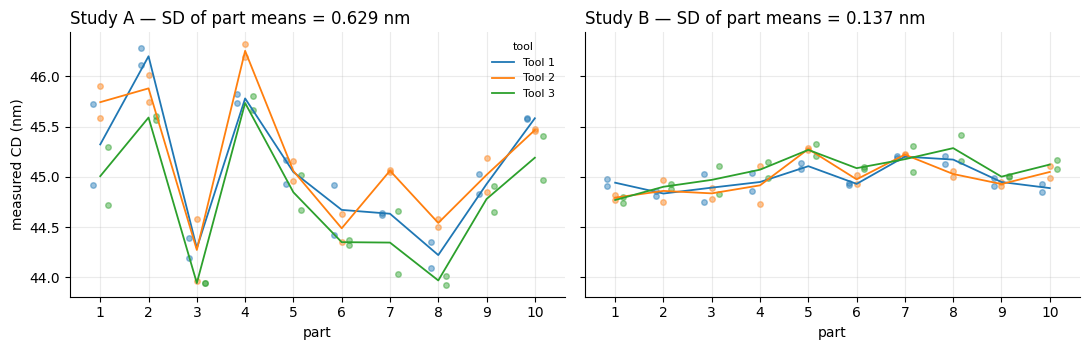

Lines = each tool's mean per part (three series); dots = the individual trials.
Gap between the lines is reproducibility; scatter of dots about a line is
repeatability. Study B's parts are far more uniform — that one fact is why its
two %R&R metrics disagree in P1.


In [24]:
# ---------------------------------------------------------------- HW3 data
# --- P1: two gauge studies, 10 parts x 3 tools x 2 trials each
gA = pd.read_csv(DATA / "hw3_gauge_study_A.csv")
gB = pd.read_csv(DATA / "hw3_gauge_study_B.csv")
print(f"hw3_gauge_study_A.csv — {len(gA)} rows = "
      f"{gA['part'].nunique()} parts x {gA['tool'].nunique()} tools x 2 trials")
display(gA.head(6))

# three tools = three series over the same ten parts, plus both raw trials behind them
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, g, name in ((axes[0], gA, "A"), (axes[1], gB, "B")):
    for j, (tool, sub_) in enumerate(g.groupby("tool")):
        ax.scatter(sub_["part"] + (j - 1) * 0.16, sub_["measured_cd_nm"], s=16, alpha=0.45)
        mean_by_part = sub_.groupby("part")["measured_cd_nm"].mean()
        ax.plot(mean_by_part.index, mean_by_part.to_numpy(), "-", lw=1.3, label=tool)
    spread = g.groupby("part")["measured_cd_nm"].mean().std(ddof=1)
    ax.set_title(f"Study {name} — SD of part means = {spread:.3f} nm", loc="left")
    ax.set_xlabel("part"); ax.set_xticks(range(1, 11))
axes[0].set_ylabel("measured CD (nm)")
axes[0].legend(frameon=False, fontsize=8, title="tool", title_fontsize=8)
plt.tight_layout(); plt.show()
print("Lines = each tool's mean per part (three series); dots = the individual trials.")
print("Gap between the lines is reproducibility; scatter of dots about a line is")
print("repeatability. Study B's parts are far more uniform — that one fact is why its")
print("two %R&R metrics disagree in P1.")

hw3_etch_seasoning.csv — 120 lots; wafers_since_pm resets at each PM


,lot,wafers_since_pm,etch_rate
0,1,0,997.7960
1,2,1,999.7580
2,3,2,995.9080
3,4,3,994.6230
4,5,4,999.9640


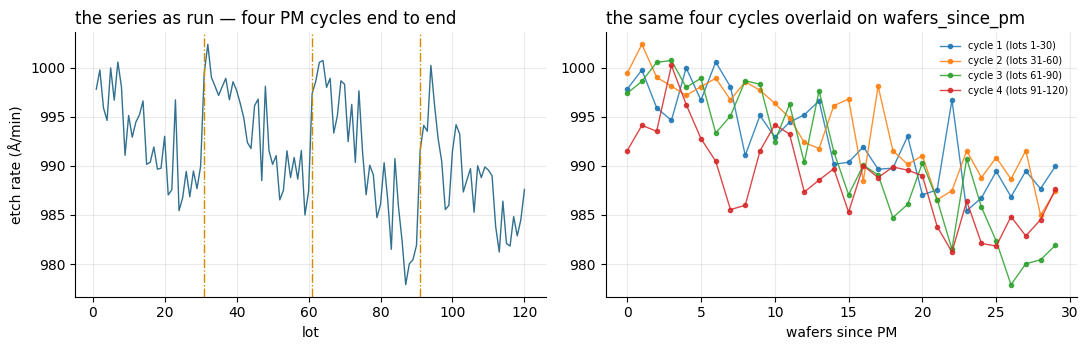

Overlaid, the four cycles trace one repeatable curve — that repeatability is what
makes the drift modellable, and the last cycle is visibly the odd one out.


In [25]:
# --- P3: 120 lots with a PM every 30 wafers; the expected drift is a supplied column
d = pd.read_csv(DATA / "hw3_etch_seasoning.csv")
print(f"hw3_etch_seasoning.csv — {len(d)} lots; wafers_since_pm resets at each PM")
display(d.head())

d = d.assign(cycle=(d["lot"] - 1) // 30 + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(d["lot"], d["etch_rate"], "-", lw=1, color=BLUE)
for m in d.loc[(d["wafers_since_pm"] == 0) & (d["lot"] > 1), "lot"]:
    axes[0].axvline(m, color="#d08c00", ls="-.", lw=1)
axes[0].set_title("the series as run — four PM cycles end to end", loc="left")
axes[0].set_xlabel("lot"); axes[0].set_ylabel("etch rate (Å/min)")

# the four PM cycles are replicate series of the same seasoning curve
for cyc, g in d.groupby("cycle"):
    axes[1].plot(g["wafers_since_pm"], g["etch_rate"], "o-", ms=3, lw=1, alpha=0.85,
                 label=f"cycle {cyc} (lots {g['lot'].min()}-{g['lot'].max()})")
axes[1].set_title("the same four cycles overlaid on wafers_since_pm", loc="left")
axes[1].set_xlabel("wafers since PM"); axes[1].legend(frameon=False, fontsize=7)
plt.tight_layout(); plt.show()
print("Overlaid, the four cycles trace one repeatable curve — that repeatability is what")
print("makes the drift modellable, and the last cycle is visibly the odd one out.")

hw3_fdc.csv — 200 runs x 12 sensors


,run,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06
0,1,-1.2108,-1.9463,-0.8945,-1.5899,1.8296,0.9915
1,2,2.4882,-1.3092,-2.0729,6.3003,-3.2347,0.9394
2,3,0.0458,-0.7944,-0.1605,0.1690,0.7759,1.1532
3,4,1.6383,-0.4574,-0.6325,3.4531,-1.9713,0.1063


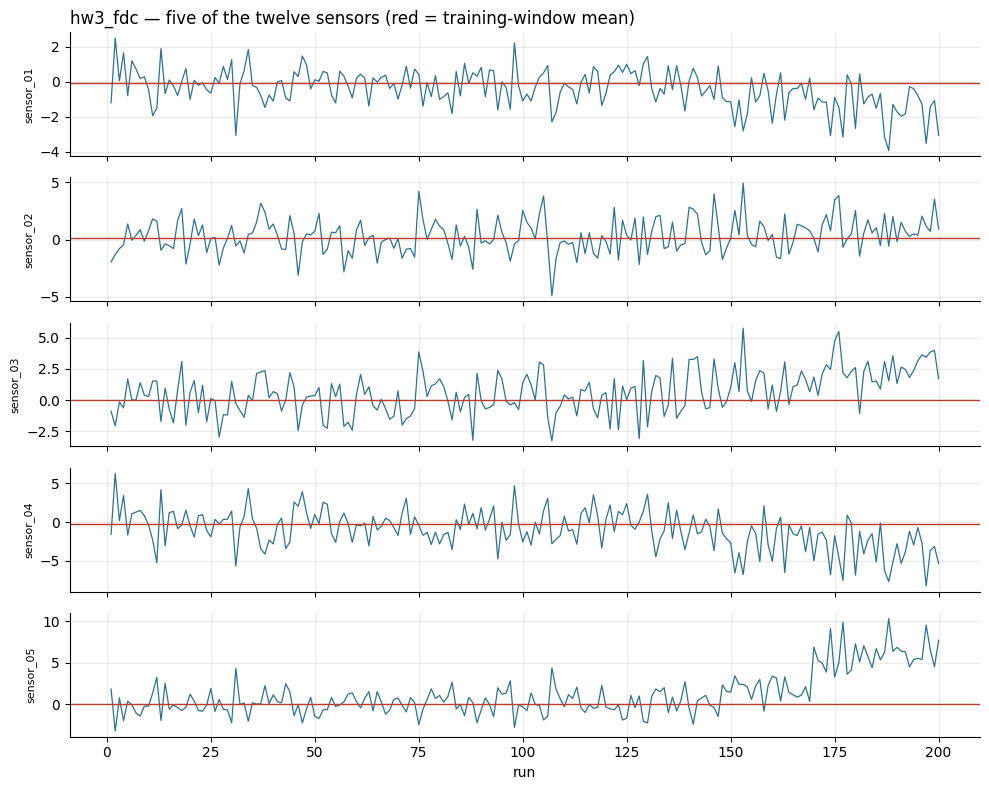

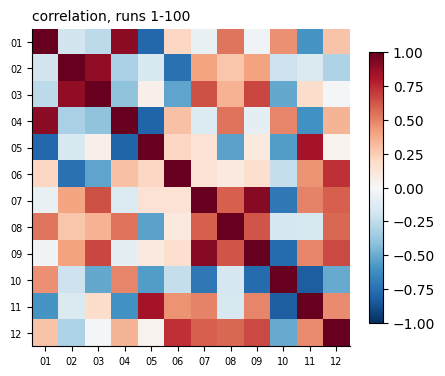

No single sensor is worth charting alone — the correlation structure is the signal.


In [26]:
# --- P4: 200 runs x 12 sensors, correlated by construction
d = pd.read_csv(DATA / "hw3_fdc.csv")
scols = [c for c in d.columns if c.startswith("sensor")]
print(f"hw3_fdc.csv — {len(d)} runs x {len(scols)} sensors")
display(d.head(4).iloc[:, :7])

# five of the twelve sensors, one panel each — each looks unremarkable on its own
show = scols[:5]
fig, axes = plt.subplots(5, 1, figsize=(10, 8), sharex=True)
for ax, c in zip(axes, show):
    ax.plot(d["run"], d[c], "-", lw=0.9, color=BLUE)
    ax.axhline(d[c].iloc[:100].mean(), color=RED, lw=1)
    ax.set_ylabel(c, fontsize=8)
axes[0].set_title("hw3_fdc — five of the twelve sensors (red = training-window mean)",
                  loc="left")
axes[-1].set_xlabel("run")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(4.6, 3.8))
im = ax.imshow(d[scols].iloc[:100].corr(), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(12), [c[-2:] for c in scols], fontsize=7)
ax.set_yticks(range(12), [c[-2:] for c in scols], fontsize=7)
ax.set_title("correlation, runs 1-100", loc="left", fontsize=10)
ax.grid(False); fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout(); plt.show()
print("No single sensor is worth charting alone — the correlation structure is the signal.")

hw3_r2r_loop.csv — 120 lots, EWMA controller with lambda = 0.25


,lot,output_error,controller_offset
0,1,-0.4812,0.1203
1,2,-0.6743,0.2889
2,3,0.1399,0.2539
3,4,0.5062,0.1274
4,5,0.8090,-0.0749


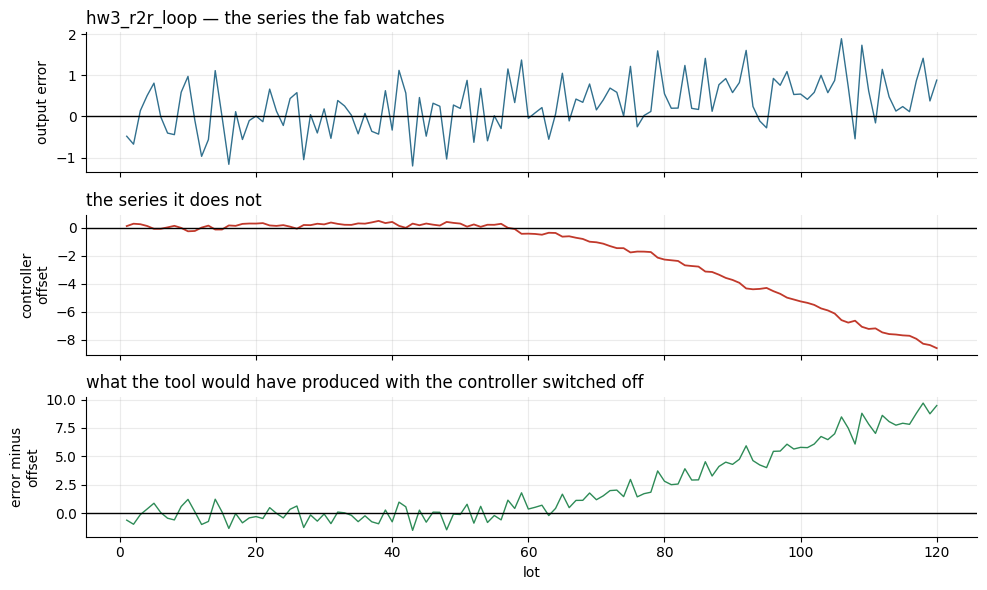

Both recorded series are in the CSV. The bottom panel is derived, and it is the one
that shows the tool actually degrading.


In [27]:
# --- P5: a closed loop, 120 lots — both the error and the correction are recorded
d = pd.read_csv(DATA / "hw3_r2r_loop.csv")
print(f"hw3_r2r_loop.csv — {len(d)} lots, EWMA controller with lambda = 0.25")
display(d.head())

# two recorded series, and the third one implied by them
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
axes[0].plot(d["lot"], d["output_error"], lw=1, color=BLUE)
axes[0].axhline(0, color="k", lw=1)
axes[0].set_ylabel("output error")
axes[0].set_title("hw3_r2r_loop — the series the fab watches", loc="left")

axes[1].plot(d["lot"], d["controller_offset"], lw=1.3, color=RED)
axes[1].axhline(0, color="k", lw=1)
axes[1].set_ylabel("controller\noffset")
axes[1].set_title("the series it does not", loc="left")

axes[2].plot(d["lot"], d["output_error"] - d["controller_offset"], lw=1, color="#2e8b57")
axes[2].axhline(0, color="k", lw=1)
axes[2].set_ylabel("error minus\noffset")
axes[2].set_xlabel("lot")
axes[2].set_title("what the tool would have produced with the controller switched off",
                  loc="left")
plt.tight_layout(); plt.show()
print("Both recorded series are in the CSV. The bottom panel is derived, and it is the one")
print("that shows the tool actually degrading.")

## P1 — Gauge R&R
*Data: `hw3_gauge_study_A.csv`, `hw3_gauge_study_B.csv` — 10 parts × 3 tools × 2 trials*

**The problem.** For each study, by two-way ANOVA with interaction (reproducibility =
tool + interaction):

1. Report σ for repeatability, reproducibility, combined gauge R&R, part-to-part, and total.
2. Compute the three standard acceptance metrics:
   - %R&R against tolerance = 6σ_R&R / (USL − LSL)
   - %R&R against total variation = σ_R&R / σ_total
   - number of distinct categories, ndc = 1.41 × σ_part / σ_R&R
3. Give the verdict for each (< 10% acceptable, 10–30% conditional, > 30% unacceptable;
   ndc ≥ 5 required).
4. One study's metrics disagree with each other. Explain why, and decide which metric governs
   which decision.

Study A is CD-SEM #1 — the tool that measured the HW2 data. Study B is CD-SEM #2, measured on
a different set of ten parts.

In [28]:
def anova_grr(df, value="measured_cd_nm", part="part", op="tool"):
    "Crossed two-way ANOVA gauge R&R. Returns variance components (nm^2)."
    P, O = df[part].nunique(), df[op].nunique()
    T = len(df) // (P * O)
    g = df[value].mean()
    mp = df.groupby(part)[value].mean()
    mo = df.groupby(op)[value].mean()
    mpo = df.groupby([part, op])[value].mean()

    SSP = O * T * ((mp - g) ** 2).sum()
    SSO = P * T * ((mo - g) ** 2).sum()
    SSPO = T * ((mpo
                 - mpo.index.get_level_values(0).map(mp)
                 - mpo.index.get_level_values(1).map(mo) + g) ** 2).sum()
    SSE = ((df[value] - df.set_index([part, op]).index.map(mpo)) ** 2).sum()

    MSP, MSO = SSP / (P - 1), SSO / (O - 1)
    MSPO, MSE = SSPO / ((P - 1) * (O - 1)), SSE / (P * O * (T - 1))

    v_rep = MSE                                       # equipment
    v_op = max((MSO - MSPO) / (P * T), 0)             # tool-to-tool
    v_int = max((MSPO - MSE) / T, 0)                  # part x tool interaction
    v_part = max((MSP - MSPO) / (O * T), 0)
    v_grr = v_rep + v_op + v_int
    return dict(rep=v_rep, op=v_op, inter=v_int, grr=v_grr,
                part=v_part, total=v_grr + v_part)


def grr_report(name):
    df = pd.read_csv(DATA / f"hw3_gauge_study_{name}.csv")
    v = anova_grr(df)
    s = {k: np.sqrt(val) for k, val in v.items()}
    s_repro = np.sqrt(v["op"] + v["inter"])
    pct_tol = 6 * s["grr"] / TOL * 100
    pct_tv = s["grr"] / s["total"] * 100
    ndc = 1.41 * s["part"] / s["grr"]
    tbl = pd.DataFrame({
        "component": ["repeatability (equipment)", "reproducibility (tool-to-tool)",
                      "GAUGE R&R", "part-to-part", "total"],
        "sigma (nm)": [s["rep"], s_repro, s["grr"], s["part"], s["total"]],
        "variance (nm^2)": [v["rep"], v["op"] + v["inter"], v["grr"], v["part"], v["total"]]})
    print(f"===== Study {name} =====")
    display(tbl.style.format({"sigma (nm)": "{:.4f}",
                              "variance (nm^2)": "{:.5f}"}).hide(axis="index"))
    verdict = lambda p: ("acceptable" if p < 10 else
                         "conditionally acceptable" if p < 30 else "UNACCEPTABLE")
    print(f"  %R&R vs tolerance = 6 x {s['grr']:.4f} / {TOL} = {pct_tol:.1f}%"
          f"   -> {verdict(pct_tol)}")
    print(f"  %R&R vs total var = {s['grr']:.4f} / {s['total']:.4f} = {pct_tv:.1f}%"
          f"   -> {verdict(pct_tv)}")
    print(f"  ndc = 1.41 x {s['part']:.4f} / {s['grr']:.4f} = {ndc:.1f}"
          f"   -> {'acceptable' if ndc >= 5 else 'UNACCEPTABLE (below 5)'}\n")
    return dict(df=df, s_grr=s["grr"], s_part=s["part"], s_tot=s["total"],
                pct_tol=pct_tol, pct_tv=pct_tv, ndc=ndc)


A = grr_report("A")     # CD-SEM #1 — the tool that measured the HW2 data
B = grr_report("B")     # CD-SEM #2

RESULTS.update({"grrA_sgrr": (A["s_grr"], 0.3034), "grrA_pct_tol": (A["pct_tol"], 45.5),
                "grrA_pct_tv": (A["pct_tv"], 43.9), "grrA_ndc": (A["ndc"], 2.9),
                "grrB_sgrr": (B["s_grr"], 0.1107), "grrB_pct_tol": (B["pct_tol"], 16.6),
                "grrB_pct_tv": (B["pct_tv"], 64.8), "grrB_ndc": (B["ndc"], 1.7)})

===== Study A =====


component,sigma (nm),variance (nm^2)
repeatability (equipment),0.2265,0.05132
reproducibility (tool-to-tool),0.2019,0.04075
GAUGE R&R,0.3034,0.09207
part-to-part,0.6219,0.38674
total,0.6920,0.47881


  %R&R vs tolerance = 6 x 0.3034 / 4.0 = 45.5%   -> UNACCEPTABLE
  %R&R vs total var = 0.3034 / 0.6920 = 43.9%   -> UNACCEPTABLE
  ndc = 1.41 x 0.6219 / 0.3034 = 2.9   -> UNACCEPTABLE (below 5)

===== Study B =====


component,sigma (nm),variance (nm^2)
repeatability (equipment),0.1028,0.01056
reproducibility (tool-to-tool),0.0411,0.00169
GAUGE R&R,0.1107,0.01226
part-to-part,0.1302,0.01696
total,0.1709,0.02921


  %R&R vs tolerance = 6 x 0.1107 / 4.0 = 16.6%   -> conditionally acceptable
  %R&R vs total var = 0.1107 / 0.1709 = 64.8%   -> UNACCEPTABLE
  ndc = 1.41 x 0.1302 / 0.1107 = 1.7   -> UNACCEPTABLE (below 5)



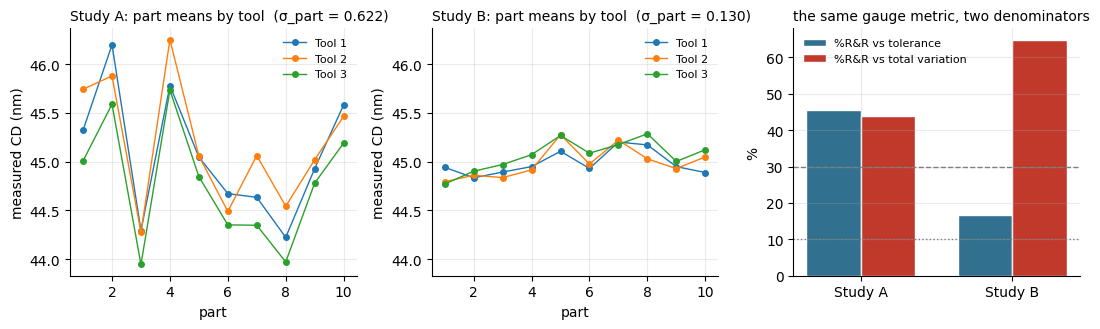

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for ax, st, name in ((axes[0], A, "A"), (axes[1], B, "B")):
    for tool, g in st["df"].groupby("tool"):
        m = g.groupby("part")["measured_cd_nm"].mean()
        ax.plot(m.index, m.to_numpy(), "o-", ms=4, lw=1, label=tool)
    ax.set_title(f"Study {name}: part means by tool  (σ_part = {st['s_part']:.3f})",
                 loc="left", fontsize=10)
    ax.set_xlabel("part"); ax.set_ylabel("measured CD (nm)")
    ax.legend(frameon=False, fontsize=8)
lo = min(axes[0].get_ylim()[0], axes[1].get_ylim()[0])
hi = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
axes[0].set_ylim(lo, hi); axes[1].set_ylim(lo, hi)      # same scale — B's parts are uniform

x = np.arange(2)
axes[2].bar(x - 0.18, [A["pct_tol"], B["pct_tol"]], 0.36, label="%R&R vs tolerance",
            color=BLUE, edgecolor="white")
axes[2].bar(x + 0.18, [A["pct_tv"], B["pct_tv"]], 0.36, label="%R&R vs total variation",
            color=RED, edgecolor="white")
axes[2].axhline(10, color=GREY, ls=":", lw=1); axes[2].axhline(30, color=GREY, ls="--", lw=1)
axes[2].annotate("30% — unacceptable above", (1.45, 31), ha="right", fontsize=8, color=GREY)
axes[2].set_xticks(x, ["Study A", "Study B"]); axes[2].set_ylabel("%")
axes[2].set_title("the same gauge metric, two denominators", loc="left", fontsize=10)
axes[2].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

### The disagreement

Study B is the interesting case: the same gauge is *conditionally acceptable* by tolerance and
*badly unacceptable* by total variation. Study A fails both, which is unambiguous.

Study B measured a set of unusually uniform parts (σ_part ≈ 0.130 nm, less than a quarter of
Study A's — visible in the middle panel above). The percentage against total variation has
part variation in its denominator, so uniform parts make the gauge look worse **with no change
to the gauge at all**.

### Which metric governs which decision

For **disposition against specification** — deciding whether material ships — use the
**tolerance-based** figure. It depends only on the gauge and the spec, both of which are
fixed. Study B's tool can decide pass/fail adequately.

For **distinguishing parts from one another** — process improvement, tool matching,
capability studies — use the total-variation figure and the ndc. On that job Study B's tool is
useless: ndc = 1.7 means it resolves fewer than two distinct levels across these parts.

There is a perverse consequence worth holding onto: a successful variation-reduction project
shrinks σ_part, which makes %R&R-against-total *worse* without the gauge having changed.

## P2 — Correct your own capability number

**The problem.** The HW2 subgroup data was measured on CD-SEM #1 — the tool characterised by
Study A. So the σ̂ computed in HW2 P1 is not the process: it is the process **and** the gauge,
added in quadrature.

1. Compute capability as measured — Cp, Cpk, ppm out of specification — from the HW2 P1 σ̂
   and X̄̄.
2. Remove the gauge: σ²_process = σ²_observed − σ²_gauge. Recompute all three.
3. Tabulate before and after, and note where Cpk lands relative to 1.0.
4. Then decide whether the corrected number changes what you would do next.

In [30]:
s_obs = sig_hat                      # from HW2 P1
s_gauge = A["s_grr"]                 # from HW3 P1 Study A
s_true = np.sqrt(max(s_obs ** 2 - s_gauge ** 2, 0))

print(f"sigma^2_process = sigma^2_observed - sigma^2_gauge")
print(f"                = {s_obs:.4f}^2 - {s_gauge:.4f}^2")
print(f"                = {s_obs**2:.5f} - {s_gauge**2:.5f} = {s_obs**2 - s_gauge**2:.5f}")
print(f"sigma_process   = {s_true:.4f} nm\n")

def capability(sig):
    Cp = TOL / (6 * sig)
    Cpk = min(USL - Xbb, Xbb - LSL) / (3 * sig)
    ppm = ((1 - stats.norm.cdf(USL, Xbb, sig)) + stats.norm.cdf(LSL, Xbb, sig)) * 1e6
    return Cp, Cpk, ppm

Cp_obs, Cpk_obs, ppm_obs = capability(s_obs)
Cp_true, Cpk_true, ppm_true = capability(s_true)

cap = pd.DataFrame({"index": ["sigma (nm)", "Cp", "Cpk", "ppm out of spec"],
                    "as measured (HW2)": [s_obs, Cp_obs, Cpk_obs, ppm_obs],
                    "gauge-corrected": [s_true, Cp_true, Cpk_true, ppm_true]})
display(cap.style.format({"as measured (HW2)": "{:,.3f}",
                          "gauge-corrected": "{:,.3f}"}).hide(axis="index"))
print(f"Cpk crosses 1.0: {Cpk_obs:.3f} -> {Cpk_true:.3f}. The predicted defect rate falls "
      f"by a factor of {ppm_obs/ppm_true:.1f}.")
print(f"Centring alone would then take Cpk from {Cpk_true:.3f} to Cp = {Cp_true:.3f} "
      f"(the process runs {Xbb-TGT:+.2f} nm high).")

RESULTS.update({"hw3p2_strue": (s_true, 0.5396), "hw3p2_Cp_obs": (Cp_obs, 1.077),
                "hw3p2_Cpk_obs": (Cpk_obs, 0.888), "hw3p2_ppm_obs": (ppm_obs, 3921),
                "hw3p2_Cp_true": (Cp_true, 1.235), "hw3p2_Cpk_true": (Cpk_true, 1.019),
                "hw3p2_ppm_true": (ppm_true, 1122)})

sigma^2_process = sigma^2_observed - sigma^2_gauge
                = 0.6191^2 - 0.3034^2
                = 0.38324 - 0.09207 = 0.29116
sigma_process   = 0.5396 nm



index,as measured (HW2),gauge-corrected
sigma (nm),0.619,0.540
Cp,1.077,1.235
Cpk,0.888,1.019
ppm out of spec,"3,919.002","1,121.228"


Cpk crosses 1.0: 0.888 -> 1.019. The predicted defect rate falls by a factor of 3.5.
Centring alone would then take Cpk from 1.019 to Cp = 1.235 (the process runs +0.35 nm high).


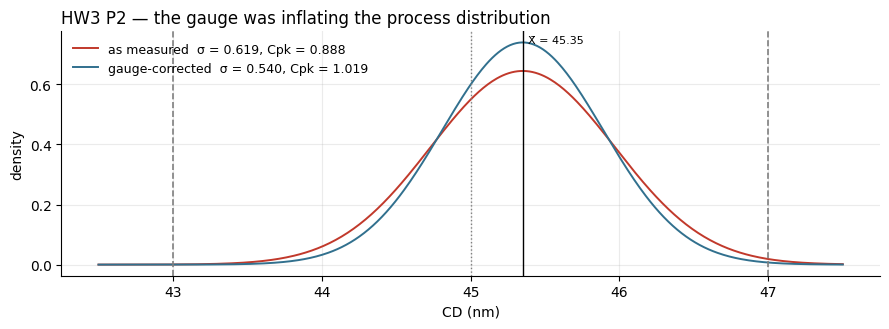

In [31]:
fig, ax = plt.subplots(figsize=(9, 3.4))
grid = np.linspace(42.5, 47.5, 500)
ax.plot(grid, stats.norm.pdf(grid, Xbb, s_obs), color=RED, lw=1.4,
        label=f"as measured  σ = {s_obs:.3f}, Cpk = {Cpk_obs:.3f}")
ax.plot(grid, stats.norm.pdf(grid, Xbb, s_true), color=BLUE, lw=1.4,
        label=f"gauge-corrected  σ = {s_true:.3f}, Cpk = {Cpk_true:.3f}")
for lim in (LSL, USL):
    ax.axvline(lim, color=GREY, ls="--", lw=1.2)
ax.axvline(TGT, color=GREY, ls=":", lw=1)
ax.axvline(Xbb, color="k", lw=1)
ax.annotate(f"X̄̄ = {Xbb:.2f}", (Xbb, ax.get_ylim()[1] * 0.95), xytext=(4, 0),
            textcoords="offset points", fontsize=8)
ax.set_title("HW3 P2 — the gauge was inflating the process distribution", loc="left")
ax.set_xlabel("CD (nm)"); ax.set_ylabel("density"); ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

### Does the conclusion change?

Both halves matter, and the first one alone is a trap:

1. **The process is better than it looked.** A capital project aimed at the *process* is not
   yet justified — you would be paying to remove variance that is not there.
2. **The gauge is unacceptable** at 45.5% of tolerance and ndc = 2.9. It has to be fixed
   first, and not only for reporting: until it is fixed you cannot measure whether any process
   improvement worked. The measurement system is on the critical path.

**Order of work:** fix or replace the metrology (better recipe, more site averaging, tool
matching across the fleet) → re-measure capability → *then* decide whether the process needs
work. And note the free improvement still sitting there: the process runs 0.35 nm high, so
centring alone would take corrected Cpk from 1.019 to Cp = 1.235.

## P3 — Residual charting
*Data: `hw3_etch_seasoning.csv`, 120 lots, PM resets at 0/30/60/90*

**The problem.** The chamber seasons as it runs: the etch rate drifts predictably between
PMs and resets at each one. Process engineering gives the expected behaviour as
`1000 − 0.42 × wafers_since_pm`, and `wafers_since_pm` is a column in the CSV.

1. Build a naive individuals chart on the raw etch rate and count the violations.
2. Form the residual, `etch_rate − expected`, and chart that instead, estimating its centre
   line and σ̂ from an early window you are willing to call clean.
3. Compare the two: violations before and after lot 76, totals, and the two σ̂ estimates.
4. Report the first residual violation and the delay between it and the onset of the change.
5. Then state the general principle in one sentence.

In [32]:
seas_df = pd.read_csv(DATA / "hw3_etch_seasoning.csv")
etch = seas_df["etch_rate"].to_numpy()
since_pm = seas_df["wafers_since_pm"].to_numpy()

# --- naive I chart on the raw rate
cl_raw = etch.mean(); s_raw = sigma_from_mr(etch)
UCL_raw, LCL_raw = cl_raw + 3 * s_raw, cl_raw - 3 * s_raw
v_raw = np.where((etch > UCL_raw) | (etch < LCL_raw))[0] + 1

# --- the model, and the chart on its residual (limits from the clean window, lots 1-70)
model = 1000 - 0.42 * since_pm
resid = etch - model
cl_r = resid[:70].mean(); s_r = sigma_from_mr(resid[:70])
UCL_r, LCL_r = cl_r + 3 * s_r, cl_r - 3 * s_r
v_res = np.where((resid > UCL_r) | (resid < LCL_r))[0] + 1

FAULT = 76
split = lambda v: (int((v < FAULT).sum()), int((v >= FAULT).sum()))
tbl = pd.DataFrame({
    "": ["centre line", "sigma-hat (MR-bar/1.128)", "limits",
         "violations BEFORE lot 76", "violations FROM lot 76", "total violations"],
    "naive I chart on raw etch rate":
        [f"{cl_raw:.2f}", f"{s_raw:.3f}", f"{LCL_raw:.1f} - {UCL_raw:.1f}",
         split(v_raw)[0], split(v_raw)[1], len(v_raw)],
    "chart on the residual":
        [f"{cl_r:.2f}", f"{s_r:.3f}", f"{LCL_r:.2f} - {UCL_r:.2f}",
         split(v_res)[0], split(v_res)[1], len(v_res)]})
display(tbl.style.hide(axis="index"))

first = int(v_res[v_res >= FAULT][0])
print(f"first residual violation after the planted onset at lot {FAULT}: lot {first} "
      f"({first-FAULT} lots of detection delay — report it honestly rather than round away)")
print(f"sigma-hat falls from {s_raw:.3f} to {s_r:.3f}, close to the true noise level of 2.6,")
print("because the deterministic drift no longer inflates the moving range.")
print(f"\n{split(v_raw)[0]} false alarms avoided: every pre-fault violation on the naive "
      "chart is the seasoning cycle being flagged as a fault.")

RESULTS.update({"hw3p3_sraw": (s_raw, 2.871), "hw3p3_sr": (s_r, 2.561),
                "hw3p3_nraw": (len(v_raw), 14), "hw3p3_nres": (len(v_res), 8),
                "hw3p3_first": (first, 83)})

,naive I chart on raw etch rate,chart on the residual
centre line,991.47,-0.63
sigma-hat (MR-bar/1.128),2.871,2.561
limits,982.9 - 1000.1,-8.32 - 7.05
violations BEFORE lot 76,4,0
violations FROM lot 76,10,8
total violations,14,8


first residual violation after the planted onset at lot 76: lot 83 (7 lots of detection delay — report it honestly rather than round away)
sigma-hat falls from 2.871 to 2.561, close to the true noise level of 2.6,
because the deterministic drift no longer inflates the moving range.

4 false alarms avoided: every pre-fault violation on the naive chart is the seasoning cycle being flagged as a fault.


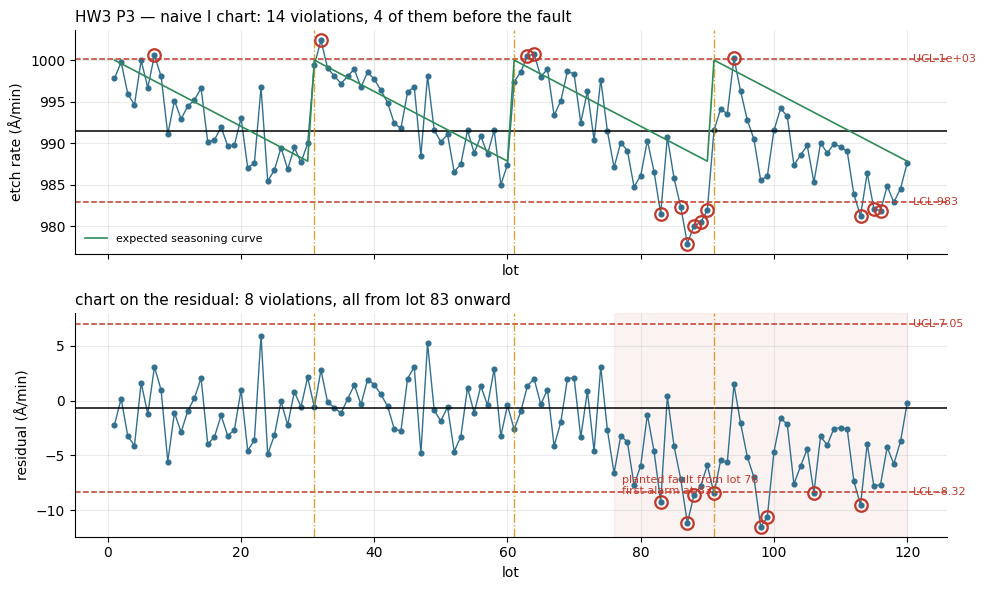

dashed vertical lines = PM events (the seasoning clock resets)


In [33]:
pm_marks = [i + 1 for i in range(1, len(since_pm)) if since_pm[i] == 0]
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

chart(etch, cl_raw, LCL_raw, UCL_raw,
      f"HW3 P3 — naive I chart: {len(v_raw)} violations, {split(v_raw)[0]} of them before the fault",
      "etch rate (Å/min)", viol=v_raw, ax=axes[0], marks=pm_marks)
axes[0].plot(np.arange(1, 121), model, color="#2e8b57", lw=1.2, ls="-",
             label="expected seasoning curve")
axes[0].legend(frameon=False, fontsize=8, loc="lower left")

chart(resid, cl_r, LCL_r, UCL_r,
      f"chart on the residual: {len(v_res)} violations, all from lot {first} onward",
      "residual (Å/min)", viol=v_res, ax=axes[1], marks=pm_marks)
axes[1].axvspan(FAULT, 120, color=RED, alpha=0.06)
axes[1].annotate(f"planted fault from lot {FAULT}\nfirst alarm at {first}", (FAULT, LCL_r),
                 xytext=(6, -2), textcoords="offset points", fontsize=8, color=RED)
plt.tight_layout(); plt.show()
print("dashed vertical lines = PM events (the seasoning clock resets)")

### The general principle

*Build a model of what you expect, chart the difference, and an alarm then means "the process
departed from what we understand about it" rather than "the number moved."*

This generalises well beyond etch. Anything with a known deterministic component qualifies —
instrument warm-up drift, seasonal effects, a calibration that ages, a battery discharge
curve. The work is in correctly identifying the *expected* component; what remains after
subtracting it is what deserves a control chart.

## P4 — Multivariate
*Data: `hw3_fdc.csv`, 200 runs × 12 sensors. Training window: runs 1–100.*

**The problem.** Twelve correlated sensors on one chamber. Charting each one separately gives
twelve charts and no information about the relationships between them.

1. Centre on the training-window mean, fit PCA to runs 1–100, and justify keeping 3
   components.
2. For all 200 runs compute **T²** (distance *within* the model) and **SPE** (squared residual
   *outside* it).
3. Set 99% limits from the training window and chart both statistics.
4. Report violations and means in four windows — 1–100, 101–139, 140–169, 170–200 — and
   describe how the two statistics differ in what they respond to.
5. For a flagged run late in the series (use run 185), rank each sensor's contribution to SPE.
6. Then decide what you would check before dispatching anyone to swap hardware.

In [34]:
fdc = pd.read_csv(DATA / "hw3_fdc.csv")
sensors = [c for c in fdc.columns if c.startswith("sensor")]
X = fdc[sensors].to_numpy()
NR, NS = X.shape
TRAIN = 100

mu = X[:TRAIN].mean(0)
Xc = X - mu                                    # centred on the training window only
U, S, Vt = np.linalg.svd(Xc[:TRAIN], full_matrices=False)
var_exp = S ** 2 / (S ** 2).sum()

k = 3
P = Vt[:k].T                                   # loadings
T = Xc @ P                                     # scores
lam = S[:k] ** 2 / (TRAIN - 1)                 # score variances from the training window
T2 = ((T ** 2) / lam).sum(1)
E = Xc - T @ P.T                               # residual matrix
SPE = (E ** 2).sum(1)

lim_T2 = np.percentile(T2[:TRAIN], 99)
lim_SPE = np.percentile(SPE[:TRAIN], 99)

print(f"variance explained by the first {k} PCs: {var_exp[:k].sum()*100:.1f}%")
print(f"  individually: {np.round(var_exp[:5]*100, 1)}  <- clear elbow after the 3rd")
print(f"99% limits from the training window:  T2 = {lim_T2:.2f}   SPE = {lim_SPE:.2f}\n")

WINDOWS = [("1-100 (training)", 0, 100), ("101-139 (clean)", 100, 139),
           ("140-169 (in-model drift)", 139, 169), ("170-200 (sensor-5 fault)", 169, 200)]
wt = pd.DataFrame([(lab, int((T2[a:b] > lim_T2).sum()), int((SPE[a:b] > lim_SPE).sum()),
                    T2[a:b].mean(), SPE[a:b].mean()) for lab, a, b in WINDOWS],
                  columns=["window", "T2 violations", "SPE violations", "T2 mean", "SPE mean"])
display(wt.style.format({"T2 mean": "{:.2f}", "SPE mean": "{:.2f}"}).hide(axis="index"))

print("The drift planted at run 140 moves T2 only — the process moved along a direction the")
print("model already knows about. The sensor-5 offset at run 170 moves SPE hard: the")
print("correlation structure itself broke.")
print("1 violation in the 100-run training window and ~3 per 39 clean runs are consistent")
print("with a 99% limit — expected false alarms, not early detection.")

RESULTS.update({"hw3p4_ve": (var_exp[:3].sum() * 100, 95.4),
                "hw3p4_limT2": (lim_T2, 10.43), "hw3p4_limSPE": (lim_SPE, 2.52),
                "hw3p4_T2_170": (int((T2[169:] > lim_T2).sum()), 26),
                "hw3p4_SPE_170": (int((SPE[169:] > lim_SPE).sum()), 31)})

variance explained by the first 3 PCs: 95.4%
  individually: [43.7 30.7 21.1  0.8  0.7]  <- clear elbow after the 3rd
99% limits from the training window:  T2 = 10.43   SPE = 2.52



window,T2 violations,SPE violations,T2 mean,SPE mean
1-100 (training),1,1,2.97,1.09
101-139 (clean),3,1,4.05,1.17
140-169 (in-model drift),3,0,6.20,1.15
170-200 (sensor-5 fault),26,31,21.33,9.45


The drift planted at run 140 moves T2 only — the process moved along a direction the
model already knows about. The sensor-5 offset at run 170 moves SPE hard: the
correlation structure itself broke.
1 violation in the 100-run training window and ~3 per 39 clean runs are consistent
with a 99% limit — expected false alarms, not early detection.


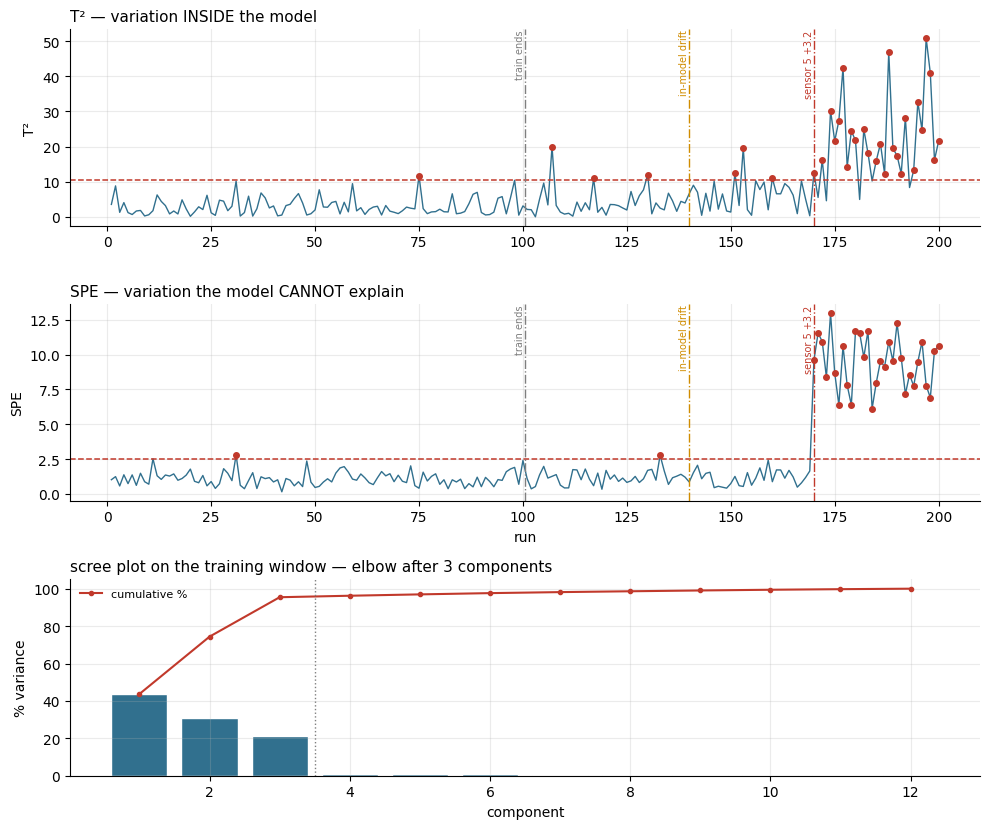

In [35]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8.4))
for ax, stat, lim, nm in ((axes[0], T2, lim_T2, "T² — variation INSIDE the model"),
                          (axes[1], SPE, lim_SPE, "SPE — variation the model CANNOT explain")):
    ax.plot(np.arange(1, NR + 1), stat, "-", lw=1, color=BLUE)
    ax.axhline(lim, color=RED, ls="--", lw=1.1)
    hits = np.where(stat > lim)[0]
    ax.plot(hits + 1, stat[hits], "o", ms=4, color=RED)
    for run, lab, col in ((100.5, "train ends", GREY), (140, "in-model drift", "#d08c00"),
                          (170, "sensor 5 +3.2", RED)):
        ax.axvline(run, color=col, ls="-.", lw=1)
        ax.annotate(lab, (run, ax.get_ylim()[1]), rotation=90, fontsize=7,
                    color=col, va="top", ha="right")
    ax.set_title(nm, loc="left", fontsize=11); ax.set_ylabel(nm.split(" ")[0])
axes[1].set_xlabel("run")

axes[2].bar(np.arange(1, 13), var_exp[:12] * 100, color=BLUE, edgecolor="white")
axes[2].plot(np.arange(1, 13), np.cumsum(var_exp[:12]) * 100, "o-", ms=3, color=RED,
             label="cumulative %")
axes[2].axvline(3.5, color=GREY, ls=":", lw=1)
axes[2].set_title("scree plot on the training window — elbow after 3 components",
                  loc="left", fontsize=11)
axes[2].set_xlabel("component"); axes[2].set_ylabel("% variance")
axes[2].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

sensor,contribution to SPE,share
sensor_05,5.224,65.4%
sensor_02,0.808,10.1%
sensor_01,0.676,8.5%
sensor_08,0.354,4.4%
sensor_04,0.316,4.0%


sensor_05 dominates at 65% — the contribution plot has found the fault.


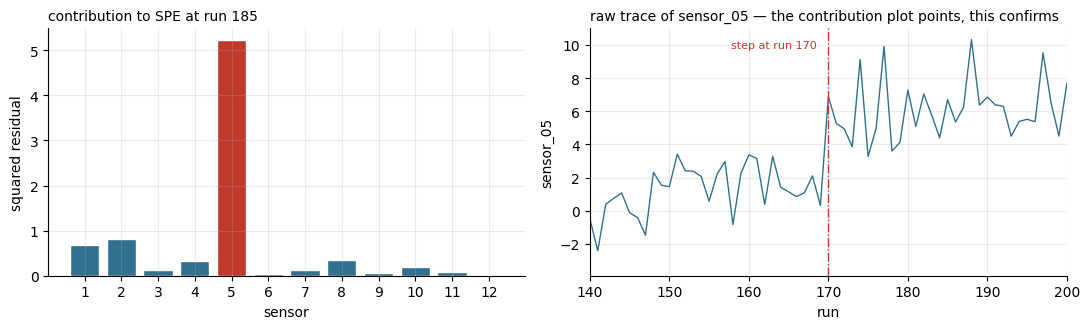

In [36]:
RUN = 185
contrib = E[RUN - 1] ** 2
order = np.argsort(contrib)[::-1]
top = pd.DataFrame({"sensor": [sensors[i] for i in order[:5]],
                    "contribution to SPE": contrib[order[:5]],
                    "share": contrib[order[:5]] / contrib.sum()})
display(top.style.format({"contribution to SPE": "{:.3f}",
                          "share": "{:.1%}"}).hide(axis="index"))
print(f"{sensors[order[0]]} dominates at {contrib[order[0]]/contrib.sum():.0%} — "
      "the contribution plot has found the fault.")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
cols = [RED if i == order[0] else BLUE for i in range(NS)]
axes[0].bar(range(1, NS + 1), contrib, color=cols, edgecolor="white")
axes[0].set_xticks(range(1, NS + 1))
axes[0].set_title(f"contribution to SPE at run {RUN}", loc="left", fontsize=10)
axes[0].set_xlabel("sensor"); axes[0].set_ylabel("squared residual")

# the confirmation step: the contribution plot points, the raw trace confirms
axes[1].plot(np.arange(1, NR + 1), X[:, 4], lw=1, color=BLUE)
axes[1].axvline(170, color=RED, ls="-.", lw=1)
axes[1].annotate("step at run 170", (170, X[:, 4].max()), xytext=(-70, -6),
                 textcoords="offset points", fontsize=8, color=RED)
axes[1].set_xlim(140, 200)
axes[1].set_title("raw trace of sensor_05 — the contribution plot points, this confirms",
                  loc="left", fontsize=10)
axes[1].set_xlabel("run"); axes[1].set_ylabel("sensor_05")
plt.tight_layout(); plt.show()

RESULTS["hw3p4_share"] = (contrib[order[0]] / contrib.sum() * 100, 65.4)

### Validating the suspect before anyone touches hardware

The contribution plot names sensor 5. It is a pointer, not a diagnosis. Before acting:

- **The 35% that is not sensor 5 is smearing**, not five additional faults. Sensors 1, 2, 4
  and 8 are correlated with 5, so a fault in 5 leaks into their contributions.
- **Plot the raw trace of sensor 5** across runs 150–200 and confirm the step at 170 — the
  contribution plot points, the raw data confirms (right panel below).
- **Rebuild the PCA model excluding sensor 5.** If SPE returns to normal, sensor 5 was the
  cause. If it does not, the fault is elsewhere and sensor 5 was merely smeared into.
- **Check whether it is the sensor or the process.** A failed transducer and a genuine process
  change look identical in the data. Cross-reference maintenance logs and any redundant
  measurement.

The same caution applies to SHAP or any other attribution on a neural network, for exactly the
same reason: correlated inputs share credit, so attribution locates a *region* of the input
space, not a cause. Treating the contribution plot as proof and stopping is the failure mode
this problem exists to demonstrate.

## P5 — The closed loop *(bonus)*
*Data: `hw3_r2r_loop.csv`, 120 lots, EWMA controller λ = 0.25*

**The problem.** A closed loop: the controller observes each lot's error and adjusts the
recipe for the next. Both the error and the correction are recorded — most fabs chart only the
first.

1. Chart `output_error` as individuals, with σ̂ from an early clean window, and count
   violations.
2. Chart `controller_offset` the same way, and count violations there.
3. Estimate σ̂ for the offset two ways — MR̄/1.128 and the clean-window standard deviation.
   They disagree; decide which to use and why (something from HW2 P3 is relevant).
4. Report the first offset violation and the total drift over the 120 lots.
5. Then work out what happened to this tool, when, and why the output chart stayed silent.

In [37]:
r2r = pd.read_csv(DATA / "hw3_r2r_loop.csv")
err = r2r["output_error"].to_numpy()
off = r2r["controller_offset"].to_numpy()
CLEAN = 50                                   # lots known to be healthy

s_o = sigma_from_mr(err[:CLEAN])
v_o = np.where(np.abs(err) > 3 * s_o)[0] + 1          # the controller targets zero error

s_c_mr = sigma_from_mr(off[:CLEAN])
s_c = off[:CLEAN].std(ddof=1)                # the offset is autocorrelated BY CONSTRUCTION
cl_c = off[:CLEAN].mean()
UCL_c, LCL_c = cl_c + 3 * s_c, cl_c - 3 * s_c
v_c = np.where((off > UCL_c) | (off < LCL_c))[0] + 1

print(f"offset sigma-hat: MR-bar based {s_c_mr:.3f} vs clean-window SD {s_c:.3f}")
print("   -> use the SD. The EWMA controller makes the offset autocorrelated by design, so")
print("      the moving range understates sigma. This is HW2 P3 appearing again, in a")
print("      place where nobody warns you to look for it.\n")

loop = pd.DataFrame({
    "chart": ["output error", "controller offset"],
    "sigma-hat": [s_o, s_c],
    "limits": [f"+/-{3*s_o:.2f}", f"{LCL_c:.2f} to {UCL_c:.2f}"],
    "violations": [len(v_o), len(v_c)],
    "first violation": ["-", int(v_c[0]) if len(v_c) else "-"]})
display(loop.style.format({"sigma-hat": "{:.3f}"}).hide(axis="index"))
print(f"the controller offset drifts from ~0 to {off[-1]:.2f} over the run")
print(f"\nSomething began degrading near lot 60. The output chart never fired because the")
print("controller absorbed the fault, lot by lot, by winding in a compensating offset.")
print("The output chart is measuring the controller's competence, not the tool's health.")

RESULTS.update({"hw3p5_so": (s_o, 0.632), "hw3p5_sc": (s_c, 0.169),
                "hw3p5_no": (len(v_o), 0), "hw3p5_nc": (len(v_c), 62),
                "hw3p5_first": (int(v_c[0]), 59), "hw3p5_final": (off[-1], -8.59)})

offset sigma-hat: MR-bar based 0.101 vs clean-window SD 0.169
   -> use the SD. The EWMA controller makes the offset autocorrelated by design, so
      the moving range understates sigma. This is HW2 P3 appearing again, in a
      place where nobody warns you to look for it.



chart,sigma-hat,limits,violations,first violation
output error,0.632,+/-1.90,0,-
controller offset,0.169,-0.33 to 0.68,62,59


the controller offset drifts from ~0 to -8.59 over the run

Something began degrading near lot 60. The output chart never fired because the
controller absorbed the fault, lot by lot, by winding in a compensating offset.
The output chart is measuring the controller's competence, not the tool's health.


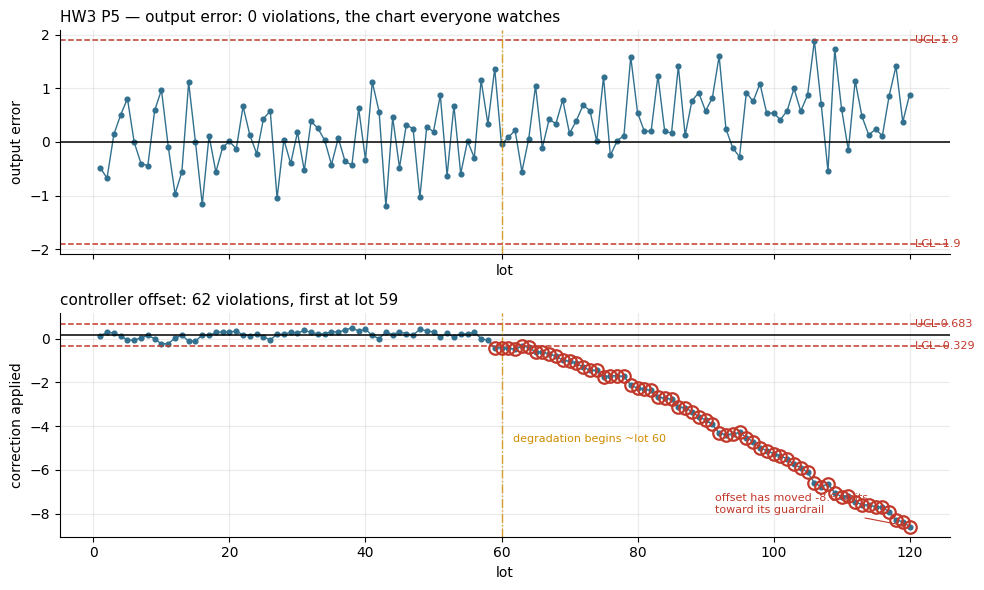

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
chart(err, 0.0, -3 * s_o, 3 * s_o,
      f"HW3 P5 — output error: {len(v_o)} violations, the chart everyone watches",
      "output error", viol=v_o, ax=axes[0], marks=[60])
chart(off, cl_c, LCL_c, UCL_c,
      f"controller offset: {len(v_c)} violations, first at lot {int(v_c[0])}",
      "correction applied", viol=v_c, ax=axes[1], marks=[60])
axes[1].annotate("degradation begins ~lot 60", (60, off.min() * 0.55), xytext=(8, 0),
                 textcoords="offset points", fontsize=8, color="#d08c00")
axes[1].annotate(f"offset has moved {off[-1]:.1f} units\ntoward its guardrail",
                 (120, off[-1]), xytext=(-140, 10), textcoords="offset points",
                 fontsize=8, color=RED,
                 arrowprops=dict(arrowstyle="->", color=RED, lw=0.8))
plt.tight_layout(); plt.show()

### Reading the result

- **Onset near lot 60.** Something began degrading there, and the offset chart flags it at
  lot 59 while the output chart never fires at all.
- **The mechanism:** the controller cancels the output error regardless of whether that error
  is ordinary drift or a developing fault. The output chart is measuring the controller's
  competence, not the tool's health.
- **The endgame:** the offset has moved 8.6 units and will eventually hit its guardrail. At
  that point the output goes out of specification suddenly, with no warning, on a process that
  had been "in control" for months.

The monitoring fix is to chart what the controller is doing as well as what it achieves: the
correction signal, the headroom remaining before the guardrail, and the rate of large moves.

---
# Appendix — p chart
*Data: `hw2_probe_yield.csv`, 30 lots, n varying 150–900*

**The problem.** Attribute data — a count, not a measurement — with a subgroup size that
changes from lot to lot.

1. Compute p̄. The correct estimate is **pooled**, total failures over total die tested, not
   the average of the per-lot fractions.
2. Build the chart. Because n varies, so do the limits: p̄ ± 3√(p̄(1−p̄)/nᵢ).
3. Report any out-of-control lots, and compare the limit half-width at n = 200 with n = 800.

A lot with more die tested gets a *tighter* test, because the limits express how much
evidence that lot provides — and a bigger sample says more about the true fraction.

In [39]:
probe = pd.read_csv(DATA / "hw2_probe_yield.csv")
nlot = probe["die_tested"].to_numpy()
fails = probe["die_failed"].to_numpy()
p = fails / nlot

pbar = fails.sum() / nlot.sum()              # POOLED — not the average of per-lot fractions
half = 3 * np.sqrt(pbar * (1 - pbar) / nlot)
ucl_p, lcl_p = pbar + half, np.maximum(pbar - half, 0)
oo_p = [int(i) for i in np.where((p > ucl_p) | (p < lcl_p))[0] + 1]

print(f"p-bar = {fails.sum()} / {nlot.sum():,} = {pbar:.4f}   "
      f"(the mean of the per-lot fractions, {p.mean():.4f}, is the wrong answer)")
for nn in (200, 800):
    print(f"  limit half-width at n = {nn}: +/-{3*np.sqrt(pbar*(1-pbar)/nn):.4f}")
print(f"out of control: lot(s) {oo_p}  ({p[np.array(oo_p)-1][0]*100:.1f}% failing, "
      "planted at 8.5% before integer truncation)")
print("The half-width doubles between the largest and smallest lots. Big lots get a tighter")
print("test because you know more about them.")

RESULTS.update({"pchart_pbar": (pbar, 0.0492), "pchart_oo": (oo_p[0], 20)})

p-bar = 730 / 14,847 = 0.0492   (the mean of the per-lot fractions, 0.0478, is the wrong answer)
  limit half-width at n = 200: +/-0.0459
  limit half-width at n = 800: +/-0.0229
out of control: lot(s) [20]  (8.4% failing, planted at 8.5% before integer truncation)
The half-width doubles between the largest and smallest lots. Big lots get a tighter
test because you know more about them.


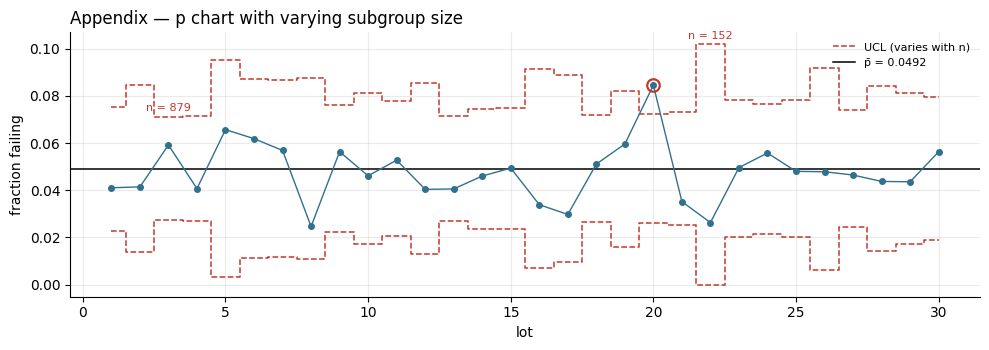

In [40]:
lots = np.arange(1, len(p) + 1)
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.step(lots, ucl_p, where="mid", color=RED, ls="--", lw=1.1, label="UCL (varies with n)")
ax.step(lots, lcl_p, where="mid", color=RED, ls="--", lw=1.1)
ax.axhline(pbar, color="k", lw=1.1, label=f"p̄ = {pbar:.4f}")
ax.plot(lots, p, "o-", ms=4, lw=1, color=BLUE)
idx = np.array(oo_p) - 1
ax.plot(lots[idx], p[idx], "o", ms=9, mfc="none", mec=RED, mew=1.6)
for i in (int(np.argmin(nlot)), int(np.argmax(nlot))):
    ax.annotate(f"n = {nlot[i]}", (lots[i], ucl_p[i]), xytext=(0, 4),
                textcoords="offset points", ha="center", fontsize=8, color=RED)
ax.set_title("Appendix — p chart with varying subgroup size", loc="left")
ax.set_xlabel("lot"); ax.set_ylabel("fraction failing")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

---
# Appendix — Summary of every planted event

| Dataset | Event | Where | Detected by |
|---|---|---|---|
| `hw2_cd_subgroups` | +0.35 nm sustained shift | lots 5–14 | X̄ Rule 4 at 14 |
| `hw2_cd_subgroups` | +1.30 nm step | lots 19–21 | X̄ Rule 1 |
| `hw2_cd_subgroups` | 3× within-lot spread | lot 26 | R chart Rule 1 only |
| `hw2_etch_ar1` | none — φ = 0.8 only | — | 26 false alarms |
| `hw3_gauge_study_A` | σ_gauge = 0.30 nm | — | 45.5% of tolerance |
| `hw3_gauge_study_B` | uniform parts | — | metrics disagree |
| `hw3_etch_seasoning` | −5 Å/min step | lot 76 | residual chart, lot 83 |
| `hw3_fdc` | in-model drift | run 140 | T² only |
| `hw3_fdc` | sensor 5 +3.2 | run 170 | SPE, 65% contribution |
| `hw3_r2r_loop` | fault ramp to +9 | lot 60 | offset chart only |